# Wind-tunnel analysis notebook — cleaned version

This notebook is a consolidated version of the current analysis workflow. It is intended to replace the repeated code blocks across the previous notebooks.

Main features:

- reads all `.lvm` files in one folder,
- parses clean and trip-wire filenames,
- computes mean \(C_p(\theta)\), \(C_D\), \(C_L\), RMS/variance of \(C_p\),
- computes Strouhal number from the time-resolved lift signal,
- stores everything in both `results_df` and `grouped_results`,
- includes reusable plotting functions for \(C_p\), \(C_D\) vs Re, \(C_L\) vs Re, normal-bar \(C_p\) plots, and batch uncertainty.

Expected filename formats:

```text
Cyl100v2_Re100k_Clean.lvm
Cyl100v2_Re100k_Trip_0.94_A27.lvm
```

Older names such as `Cyl100_Re100k_Clean.lvm` should also work, as long as the general structure is the same.


## 1. Imports and user settings

In [1]:
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# FIGURE FONT SETTINGS
# =========================
# Match this to the main text size in your LaTeX document.
# Examples:
#   \documentclass[10pt]{...} -> FIG_FONT_SIZE = 10
#   \documentclass[11pt]{...} -> FIG_FONT_SIZE = 11
#   \documentclass[12pt]{...} -> FIG_FONT_SIZE = 12
FIG_FONT_SIZE = 14

plt.rcParams.update({
    "font.size": FIG_FONT_SIZE,
    "axes.labelsize": FIG_FONT_SIZE,
    "axes.titlesize": FIG_FONT_SIZE,
    "xtick.labelsize": FIG_FONT_SIZE,
    "ytick.labelsize": FIG_FONT_SIZE,
    "legend.fontsize": FIG_FONT_SIZE,
    "figure.titlesize": FIG_FONT_SIZE,
})

# =========================
# REYNOLDS NUMBER AXIS SETTINGS
# =========================
# Re values are stored internally as full values, e.g. 100000.
# For plots, they are displayed as Re/1000, e.g. 100 for Re = 100000.
RE_AXIS_SCALE = 1000.0
RE_AXIS_LABEL = r"$Re \times 10^{3}$"

def re_axis_values(re_values):
    """Return Reynolds numbers scaled for plotting on the x-axis."""
    return np.asarray(re_values, dtype=float) / RE_AXIS_SCALE


# =========================
# USER SETTINGS
# =========================
# Default: use the folder where the notebook is opened from.
# If this does not find your .lvm files, replace Path.cwd() with your LVM folder, e.g.
# DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260514T000837Z-3-001\LVM")
DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260514T000837Z-3-001\LVM")

# Output folder for optional exported figures/tables.
OUTPUT_FOLDER = DATA_FOLDER / "processed_outputs"
OUTPUT_FOLDER.mkdir(exist_ok=True)

# Cylinder diameter [m].
D = 0.100

# 1-based pressure tap columns in the .lvm files.
# Layer 1: 0, 12, 24, ..., 348 degrees
# Layer 2: 6, 18, 30, ..., 354 degrees
LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

# Extra channels. The first of these, "pitot", is used as q_inf.
EXTRA_NAMES = ["pitot", "AoA", "F", "alpha", "P_m", "V_tunnel", "rho", "time"]

# FFT settings for Strouhal estimation from C_L(t).
REMOVE_FIRST_FRAC = 0.10
F_MIN = 1.0
F_MAX = 500.0

# Physically constrained Strouhal ranges for FFT peak picking.
# The primary range is used for the reported vortex-shedding Strouhal number.
# This prevents low-frequency modulation peaks from being misidentified as shedding.
ST_PRIMARY_RANGE = (0.12, 0.40)

# Optional secondary low-frequency range. These peaks are stored/displayed separately
# and are not used as the reported vortex-shedding Strouhal number.
ST_SECONDARY_RANGE = (0.005, 0.10)

# Strouhal estimation method used in results_df and St-vs-Re plots.
# "single": one FFT on the full signal after removing the initial transient.
# "segments": split the remaining signal into ST_N_SEGMENTS sections and use the
#             mean/median of the dominant frequencies. This is the default here.
ST_METHOD = "segments"
ST_N_SEGMENTS = 5
ST_SEGMENT_STATISTIC = "median"   # use median so split peaks do not produce non-physical averages

# Alternative Strouhal extraction methods are also computed and stored in results_df:
#   segments   -> quality-controlled segmented FFT, stored as St
#   single     -> one full-signal FFT, stored as St_single
#   welch      -> Welch-averaged PSD, stored as St_welch
#   time_peaks -> peak-to-peak timing in C_L(t), stored as St_time_peaks
#   pressure_tap -> rear pressure tap spectra, stored as St_pressure_tap
ST_PLOT_METHOD = "segments"
ST_AVAILABLE_METHODS = ("segments", "single", "welch", "time_peaks", "autocorrelation", "pressure_tap")

# Pressure-tap based Strouhal extraction, inspired by Gamst's one-tap approach.
# The default uses several rear-side taps and reports the median valid peak.
# Use PRESSURE_TAP_ANGLES = (138,) if you want the strict one-tap version.
PRESSURE_TAP_ANGLES = (120, 126, 132, 138, 144, 150, 156)
PRESSURE_TAP_SINGLE_ANGLE = 138
PRESSURE_TAP_MAX_ANGLE_ERROR = 3.1      # degrees; taps are spaced by 6 degrees
PRESSURE_TAP_METHOD = "welch"           # "welch" or "fft"
PRESSURE_TAP_MIN_VALID_TAPS = 3
PRESSURE_TAP_MIN_AMP_RATIO = 0.10       # primary-band peak / broad-band peak
PRESSURE_TAP_RELIABLE_REL_SPREAD = 0.10
PRESSURE_TAP_AMBIGUOUS_REL_SPREAD = 0.20

# Welch PSD settings. nperseg is clipped automatically if the signal is shorter.
WELCH_NPERSEG = 1024
WELCH_OVERLAP_FRAC = 0.50

# Time-domain peak detection settings.
TIME_PEAK_PROMINENCE_STD = 0.20   # prominence = this factor * std(C_L)
TIME_PEAK_MIN_CYCLES = 3          # minimum number of valid periods required
TIME_PEAK_MAX_REL_SPREAD = 0.20   # std(T) / median(T); above this -> unreliable


# Autocorrelation settings for time-domain shedding-frequency estimation.
# The method searches for a correlation peak whose lag corresponds to ST_PRIMARY_RANGE.
# These values are intentionally moderate; use the diagnostic plot to judge questionable cases.
AUTOCORR_MIN_CORRELATION = 0.20   # minimum normalized autocorrelation peak height
AUTOCORR_PEAK_SELECT_FRAC = 0.80  # accept peaks within this fraction of strongest valid peak
AUTOCORR_MAX_REL_WIDTH = 0.35     # peak width / peak lag; above this -> unreliable

# Quality control for segmented Strouhal extraction.
# A primary shedding frequency is reported only if enough segments contain a
# plausible peak and the accepted peaks form a reasonably tight cluster.
ST_MIN_VALID_SEGMENTS = 3
ST_MIN_PRIMARY_AMP_RATIO = 0.15     # primary-band peak amplitude / global spectrum peak amplitude
ST_RELIABLE_REL_SPREAD = 0.10      # std(f_valid) / median(f_valid)
ST_AMBIGUOUS_REL_SPREAD = 0.20     # above this, St is marked unreliable and set to NaN


# Batch uncertainty settings for C_D and C_L.
N_BATCHES = 5

print(f"Using DATA_FOLDER: {DATA_FOLDER}")
print(f"Number of .lvm files found: {len(list(DATA_FOLDER.glob('*.lvm')))}")


Using DATA_FOLDER: C:\Users\mpciv\Downloads\LVM-20260514T000837Z-3-001\LVM
Number of .lvm files found: 47


## 2. Helper functions

In [2]:
def read_lvm_file(file_path: Path) -> pd.DataFrame:
    """Read an LVM file with whitespace-separated columns."""
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")


def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    """Extract columns using 1-based inclusive indexing."""
    return df.iloc[:, start - 1:end].to_numpy()


def re_label_to_int(re_label: str) -> int:
    """Convert e.g. 'Re100k' to 100000."""
    return int(re_label.replace("Re", "").replace("k", "")) * 1000


def re_value_from_run(run_dict: dict) -> int:
    """Sorting helper for run dictionaries."""
    return re_label_to_int(run_dict["re"])


def parse_filename(file_path: Path) -> dict:
    """
    Parse file names such as:
    - Cyl100v2_Re100k_Clean.lvm
    - Cyl100v2_Re100k_Trip_0.94_A27.lvm
    """
    parts = file_path.stem.split("_")

    if len(parts) < 3:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    meta = {
        "file": file_path.name,
        "file_path": file_path,
        "cylinder": parts[0],
        "re": parts[1],                # e.g. Re100k
        "Re": re_label_to_int(parts[1]),
        "case": None,
        "trip_mm": None,
        "angle": None,
        "key": None,
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"
        meta["key"] = ("Clean",)

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = float(parts[3])
        meta["angle"] = int(parts[4].replace("A", ""))
        meta["key"] = ("Trip", f"{meta['trip_mm']:.2f}", str(meta["angle"]))

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta

def combine_tap_layers(layer1_values: np.ndarray, layer2_values: np.ndarray):
    """
    Combine the two pressure tap layers into one ordered circumferential distribution.

    Layer 1 is assumed to be at:
        0, 12, 24, ..., 348 degrees

    Layer 2 is assumed to be at:
        6, 18, 30, ..., 354 degrees

    Works for both:
    - 1D arrays of shape (30,)
    - 2D arrays of shape (n_samples, 30)
    """
    theta1 = np.arange(0.0, 360.0, 12.0)
    theta2 = np.arange(6.0, 360.0, 12.0)

    theta = np.r_[theta1, theta2]
    values = np.concatenate([layer1_values, layer2_values], axis=-1)

    order = np.argsort(theta)
    return theta[order], values[..., order]


def close_periodic_distribution(theta_deg: np.ndarray, values: np.ndarray):
    """Repeat the first point at 360 degrees to close a periodic distribution."""
    theta_closed = np.r_[theta_deg, 360.0]

    if values.ndim == 1:
        values_closed = np.r_[values, values[0]]
    else:
        values_closed = np.concatenate([values, values[..., [0]]], axis=-1)

    return theta_closed, values_closed


def integrate_cd_cl(theta_deg_closed: np.ndarray, cp_closed: np.ndarray):
    """
    Integrate C_p around the cylinder.

    Sign convention matches the previous notebooks:
        C_D = 0.5 * integral(C_p cos(theta) dtheta)
        C_L = 0.5 * integral(C_p sin(theta) dtheta)

    If your angle convention changes later, this is the function to check.
    """
    theta_rad = np.deg2rad(theta_deg_closed)

    C_D = 0.5 * np.trapz(cp_closed * np.cos(theta_rad), theta_rad, axis=-1)
    C_L = 0.5 * np.trapz(cp_closed * np.sin(theta_rad), theta_rad, axis=-1)

    return C_D, C_L


def batch_confidence_interval(values: np.ndarray, n_batches: int = 5, confidence: float = 0.95):
    """
    Estimate finite-sampling uncertainty by splitting a time signal into batches.

    Returns:
        batch_means, mean, std, error
    where error is the half-width of the confidence interval.
    """
    values = np.asarray(values, dtype=float)
    batches = np.array_split(values, n_batches)
    batch_means = np.array([batch.mean() for batch in batches])

    mean = batch_means.mean()
    std = batch_means.std(ddof=1)

    # Student-t multiplier. Use scipy if available; otherwise use common values.
    try:
        from scipy.stats import t
        t_value = t.ppf(0.5 + confidence / 2.0, df=n_batches - 1)
    except Exception:
        if confidence == 0.95 and n_batches == 5:
            t_value = 2.776
        else:
            t_value = 1.96

    error = t_value * std / np.sqrt(n_batches)
    return batch_means, mean, std, error


def dominant_frequency_fft(time: np.ndarray, signal: np.ndarray,
                           remove_first_frac: float = 0.10,
                           f_min: float = 1.0,
                           f_max: float = 500.0):
    """
    Find dominant frequency using FFT with a Hann window.

    Returns:
        f_dom, freqs_band, amplitude_band
    """
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    start_idx = int(remove_first_frac * len(time))
    time = time[start_idx:]
    signal = signal[start_idx:]

    if len(time) < 10:
        raise ValueError("Too few samples for FFT.")

    signal = signal - np.mean(signal)
    dt = np.mean(np.diff(time))

    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid time step. Check the time column.")

    window = np.hanning(len(signal))
    fft_vals = np.fft.rfft(signal * window)
    freqs = np.fft.rfftfreq(len(signal), d=dt)
    amplitude = np.abs(fft_vals)

    # Remove zero frequency and apply useful frequency band.
    freqs = freqs[1:]
    amplitude = amplitude[1:]

    band_mask = (freqs >= f_min) & (freqs <= f_max)
    freqs_band = freqs[band_mask]
    amplitude_band = amplitude[band_mask]

    if len(freqs_band) == 0:
        raise ValueError(f"No FFT frequencies inside selected band {f_min}–{f_max} Hz.")

    dominant_idx = np.argmax(amplitude_band)
    f_dom = freqs_band[dominant_idx]

    return f_dom, freqs_band, amplitude_band


def dominant_frequency_fft_peak(time: np.ndarray,
                                signal: np.ndarray,
                                remove_first_frac: float = 0.10,
                                f_min: float = 1.0,
                                f_max: float = 500.0):
    """
    Find the dominant frequency and its amplitude in a selected band.

    Returns:
        f_dom, amp_dom, freqs_band, amplitude_band
    """
    f_dom, freqs_band, amplitude_band = dominant_frequency_fft(
        time,
        signal,
        remove_first_frac=remove_first_frac,
        f_min=f_min,
        f_max=f_max,
    )

    if len(freqs_band) == 0:
        return np.nan, np.nan, freqs_band, amplitude_band

    idx = int(np.nanargmax(amplitude_band))
    amp_dom = amplitude_band[idx]
    return f_dom, amp_dom, freqs_band, amplitude_band


def classify_segmented_peak_quality(f_valid,
                                    min_valid_segments=ST_MIN_VALID_SEGMENTS,
                                    reliable_rel_spread=ST_RELIABLE_REL_SPREAD,
                                    ambiguous_rel_spread=ST_AMBIGUOUS_REL_SPREAD):
    """
    Classify how repeatable the accepted segment peaks are.

    Returns:
        f_summary, relative_spread, quality

    quality is one of:
        reliable   : enough valid peaks and tight frequency clustering
        ambiguous  : enough valid peaks, but frequency spread is noticeable
        unreliable : too few valid peaks or excessive spread
    """
    f_valid = np.asarray(f_valid, dtype=float)
    f_valid = f_valid[np.isfinite(f_valid)]

    if len(f_valid) < min_valid_segments:
        return np.nan, np.nan, "unreliable"

    f_summary = np.nanmedian(f_valid)

    if not np.isfinite(f_summary) or f_summary <= 0:
        return np.nan, np.nan, "unreliable"

    relative_spread = np.nanstd(f_valid, ddof=1) / f_summary if len(f_valid) > 1 else 0.0

    if relative_spread <= reliable_rel_spread:
        quality = "reliable"
    elif relative_spread <= ambiguous_rel_spread:
        quality = "ambiguous"
    else:
        # The peaks are too split to report a meaningful single shedding frequency.
        return np.nan, relative_spread, "unreliable"

    return f_summary, relative_spread, quality


def dominant_frequency_fft_segments(time: np.ndarray,
                                    signal: np.ndarray,
                                    n_segments: int = 5,
                                    remove_first_frac: float = 0.10,
                                    f_min: float = 1.0,
                                    f_max: float = 500.0,
                                    statistic: str = "median",
                                    broad_f_min: float = F_MIN,
                                    broad_f_max: float = F_MAX,
                                    min_amp_ratio: float = ST_MIN_PRIMARY_AMP_RATIO,
                                    min_valid_segments: int = ST_MIN_VALID_SEGMENTS,
                                    reliable_rel_spread: float = ST_RELIABLE_REL_SPREAD,
                                    ambiguous_rel_spread: float = ST_AMBIGUOUS_REL_SPREAD,
                                    use_quality_control: bool = True,
                                    return_info: bool = False):
    """
    Estimate the dominant shedding frequency from segmented FFTs.

    The signal is split into segments after removing the initial transient.
    For each segment, the strongest peak inside [f_min, f_max] is found. If
    use_quality_control=True, a segment is accepted only when the peak inside
    the primary band has sufficient amplitude relative to the strongest peak in
    the broad diagnostic spectrum. The reported frequency is then the median of
    the accepted primary-band peaks, provided enough segments agree.

    This avoids non-physical averages such as averaging 3 Hz and 68 Hz to obtain
    a reported peak near 40 Hz, which is not actually present in the spectrum.

    Returns:
        f_summary: selected dominant frequency [Hz], or NaN if unreliable
        f_segments: array of raw primary-band peak frequencies for each segment [Hz]
        info (optional): dictionary with quality-control details
    """
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    start_idx = int(remove_first_frac * len(time))
    time_cut = time[start_idx:]
    signal_cut = signal[start_idx:]

    if len(time_cut) < 10 * n_segments:
        raise ValueError("Too few samples for segmented FFT.")

    time_segments = np.array_split(time_cut, n_segments)
    signal_segments = np.array_split(signal_cut, n_segments)

    f_segments = []
    amp_segments = []
    amp_ratio_segments = []
    valid_mask = []

    for t_seg, s_seg in zip(time_segments, signal_segments):
        f_dom, amp_dom, _, _ = dominant_frequency_fft_peak(
            t_seg,
            s_seg,
            remove_first_frac=0.0,
            f_min=f_min,
            f_max=f_max,
        )

        try:
            _, _, _, amp_broad = dominant_frequency_fft_peak(
                t_seg,
                s_seg,
                remove_first_frac=0.0,
                f_min=broad_f_min,
                f_max=broad_f_max,
            )
            amp_global = np.nanmax(amp_broad) if len(amp_broad) else np.nan
        except Exception:
            amp_global = np.nan

        amp_ratio = amp_dom / amp_global if np.isfinite(amp_dom) and np.isfinite(amp_global) and amp_global > 0 else np.nan

        f_segments.append(f_dom)
        amp_segments.append(amp_dom)
        amp_ratio_segments.append(amp_ratio)

        if use_quality_control:
            valid_mask.append(np.isfinite(f_dom) and np.isfinite(amp_ratio) and amp_ratio >= min_amp_ratio)
        else:
            valid_mask.append(np.isfinite(f_dom))

    f_segments = np.asarray(f_segments, dtype=float)
    amp_segments = np.asarray(amp_segments, dtype=float)
    amp_ratio_segments = np.asarray(amp_ratio_segments, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)
    f_valid = f_segments[valid_mask]

    if use_quality_control:
        f_summary, relative_spread, quality = classify_segmented_peak_quality(
            f_valid,
            min_valid_segments=min_valid_segments,
            reliable_rel_spread=reliable_rel_spread,
            ambiguous_rel_spread=ambiguous_rel_spread,
        )
    else:
        if statistic == "mean":
            f_summary = np.nanmean(f_segments)
        elif statistic == "median":
            f_summary = np.nanmedian(f_segments)
        else:
            raise ValueError('statistic must be either "mean" or "median".')
        relative_spread = np.nanstd(f_segments, ddof=1) / f_summary if np.isfinite(f_summary) and f_summary > 0 and len(f_segments) > 1 else np.nan
        quality = "not_checked"

    info = {
        "quality": quality,
        "valid_mask": valid_mask,
        "n_valid_segments": int(np.sum(valid_mask)),
        "n_segments": int(n_segments),
        "relative_spread": relative_spread,
        "amp_segments": amp_segments,
        "amp_ratio_segments": amp_ratio_segments,
        "f_valid": f_valid,
        "min_amp_ratio": min_amp_ratio,
        "f_min": f_min,
        "f_max": f_max,
    }

    if return_info:
        return f_summary, f_segments, info

    return f_summary, f_segments


def st_range_to_frequency_range(st_range, U_mean, diameter=D):
    """
    Convert a Strouhal-number search range to a frequency range.

    St = fD/U  ->  f = St*U/D
    """
    st_min, st_max = st_range

    if not np.isfinite(U_mean) or U_mean <= 0:
        raise ValueError("Invalid mean velocity for Strouhal-frequency conversion.")

    f_min = st_min * U_mean / diameter
    f_max = st_max * U_mean / diameter

    return f_min, f_max



def dominant_frequency_welch(time: np.ndarray,
                             signal: np.ndarray,
                             remove_first_frac: float = REMOVE_FIRST_FRAC,
                             f_min: float = 1.0,
                             f_max: float = 500.0,
                             broad_f_min: float = F_MIN,
                             broad_f_max: float = F_MAX,
                             nperseg: int = WELCH_NPERSEG,
                             overlap_frac: float = WELCH_OVERLAP_FRAC):
    """
    Estimate dominant frequency using Welch-averaged power spectral density.

    Welch averaging is less sensitive to individual noisy FFT segments than a
    single FFT. The selected peak is still constrained to [f_min, f_max].

    Returns:
        f_dom, freqs_band, psd_band, info
    """
    try:
        from scipy.signal import welch
    except Exception as exc:
        raise ImportError("scipy.signal.welch is required for the Welch method.") from exc

    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    start_idx = int(remove_first_frac * len(time))
    time = time[start_idx:]
    signal = signal[start_idx:]

    if len(time) < 20:
        raise ValueError("Too few samples for Welch PSD.")

    signal = signal - np.nanmean(signal)
    dt = np.nanmedian(np.diff(time))
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid time step. Check the time column.")

    fs = 1.0 / dt
    nperseg_eff = int(min(nperseg, len(signal)))
    if nperseg_eff < 16:
        raise ValueError("Too few samples for Welch PSD segment length.")

    noverlap = int(overlap_frac * nperseg_eff)
    noverlap = min(max(noverlap, 0), nperseg_eff - 1)

    freqs, psd = welch(
        signal,
        fs=fs,
        window="hann",
        nperseg=nperseg_eff,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
    )

    broad_mask = (freqs >= broad_f_min) & (freqs <= broad_f_max)
    band_mask = (freqs >= f_min) & (freqs <= f_max)

    if not np.any(band_mask):
        raise ValueError(f"No Welch frequencies inside selected band {f_min}–{f_max} Hz.")

    freqs_band = freqs[band_mask]
    psd_band = psd[band_mask]
    idx = int(np.nanargmax(psd_band))
    f_dom = freqs_band[idx]
    p_dom = psd_band[idx]

    p_global = np.nanmax(psd[broad_mask]) if np.any(broad_mask) else np.nan
    amp_ratio = p_dom / p_global if np.isfinite(p_dom) and np.isfinite(p_global) and p_global > 0 else np.nan

    info = {
        "quality": "welch" if np.isfinite(f_dom) else "unavailable",
        "amp_ratio": amp_ratio,
        "nperseg": nperseg_eff,
        "noverlap": noverlap,
        "f_min": f_min,
        "f_max": f_max,
        "broad_f_min": broad_f_min,
        "broad_f_max": broad_f_max,
    }

    return f_dom, freqs_band, psd_band, info


def shedding_frequency_time_peaks(time: np.ndarray,
                                  signal: np.ndarray,
                                  U_mean: float,
                                  diameter: float = D,
                                  st_range=ST_PRIMARY_RANGE,
                                  remove_first_frac: float = REMOVE_FIRST_FRAC,
                                  prominence_std: float = TIME_PEAK_PROMINENCE_STD,
                                  min_cycles: int = TIME_PEAK_MIN_CYCLES,
                                  max_rel_spread: float = TIME_PEAK_MAX_REL_SPREAD):
    """
    Estimate shedding frequency from peak-to-peak spacing in C_L(t).

    This time-domain method is a useful cross-check for spectral methods. It is
    only reported when enough peak spacings fall inside the physically plausible
    Strouhal range and the periods are sufficiently repeatable.

    Returns:
        f_dom, St, info
    """
    try:
        from scipy.signal import find_peaks
    except Exception as exc:
        raise ImportError("scipy.signal.find_peaks is required for the time_peaks method.") from exc

    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    start_idx = int(remove_first_frac * len(time))
    time = time[start_idx:]
    signal = signal[start_idx:]

    if len(time) < 20:
        raise ValueError("Too few samples for time-domain peak detection.")

    signal = signal - np.nanmean(signal)
    dt = np.nanmedian(np.diff(time))
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid time step. Check the time column.")

    f_min, f_max = st_range_to_frequency_range(st_range, U_mean, diameter)
    min_period = 1.0 / f_max
    max_period = 1.0 / f_min

    # Avoid detecting multiple noisy peaks inside one expected shedding cycle.
    min_distance = max(int(0.6 * min_period / dt), 1)
    prominence = prominence_std * np.nanstd(signal)

    peaks, props = find_peaks(signal, distance=min_distance, prominence=prominence)

    if len(peaks) < min_cycles + 1:
        return np.nan, np.nan, {
            "quality": "unreliable",
            "n_peaks": int(len(peaks)),
            "n_valid_periods": 0,
            "relative_spread": np.nan,
            "periods": np.array([]),
            "valid_periods": np.array([]),
            "f_min": f_min,
            "f_max": f_max,
        }

    periods = np.diff(time[peaks])
    valid_period_mask = (periods >= min_period) & (periods <= max_period)
    valid_periods = periods[valid_period_mask]

    if len(valid_periods) < min_cycles:
        return np.nan, np.nan, {
            "quality": "unreliable",
            "n_peaks": int(len(peaks)),
            "n_valid_periods": int(len(valid_periods)),
            "relative_spread": np.nan,
            "periods": periods,
            "valid_periods": valid_periods,
            "f_min": f_min,
            "f_max": f_max,
        }

    T_med = np.nanmedian(valid_periods)
    rel_spread = np.nanstd(valid_periods, ddof=1) / T_med if len(valid_periods) > 1 and T_med > 0 else 0.0

    if rel_spread > max_rel_spread:
        quality = "unreliable"
        f_dom = np.nan
        St = np.nan
    else:
        quality = "time_peaks"
        f_dom = 1.0 / T_med
        St = f_dom * diameter / U_mean

    info = {
        "quality": quality,
        "n_peaks": int(len(peaks)),
        "n_valid_periods": int(len(valid_periods)),
        "relative_spread": rel_spread,
        "periods": periods,
        "valid_periods": valid_periods,
        "peak_indices": peaks,
        "f_min": f_min,
        "f_max": f_max,
        "min_period": min_period,
        "max_period": max_period,
        "prominence": prominence,
        "min_distance_samples": min_distance,
    }

    return f_dom, St, info



def shedding_frequency_autocorrelation(time: np.ndarray,
                                       signal: np.ndarray,
                                       U_mean: float,
                                       diameter: float = D,
                                       st_range=ST_PRIMARY_RANGE,
                                       remove_first_frac: float = REMOVE_FIRST_FRAC,
                                       min_correlation: float = AUTOCORR_MIN_CORRELATION,
                                       peak_select_frac: float = AUTOCORR_PEAK_SELECT_FRAC,
                                       max_rel_width: float = AUTOCORR_MAX_REL_WIDTH):
    """
    Estimate shedding frequency from the autocorrelation of C_L(t).

    The autocorrelation is computed after removing the initial transient and the
    mean signal. The period is identified as a positive-lag autocorrelation peak
    whose lag lies inside the physically plausible shedding-period range.

    Returns:
        f_dom, St, info
    """
    try:
        from scipy.signal import find_peaks, peak_widths
    except Exception as exc:
        raise ImportError("scipy.signal.find_peaks is required for the autocorrelation method.") from exc

    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    start_idx = int(remove_first_frac * len(time))
    time = time[start_idx:]
    signal = signal[start_idx:]

    if len(time) < 30:
        return np.nan, np.nan, {
            "quality": "unreliable",
            "reason": "too_few_samples",
            "lags": np.array([]),
            "autocorr": np.array([]),
        }

    dt = np.nanmedian(np.diff(time))
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid time step. Check the time column.")

    signal = signal - np.nanmean(signal)
    std = np.nanstd(signal)
    if not np.isfinite(std) or std <= 0:
        return np.nan, np.nan, {
            "quality": "unreliable",
            "reason": "zero_signal_variance",
            "lags": np.array([]),
            "autocorr": np.array([]),
        }

    # Normalized positive-lag autocorrelation.
    signal = signal / std
    corr_full = np.correlate(signal, signal, mode="full")
    corr = corr_full[len(signal) - 1:]
    normalization = np.arange(len(signal), 0, -1, dtype=float)
    corr = corr / normalization
    corr = corr / corr[0]
    lags = np.arange(len(corr), dtype=float) * dt

    f_min, f_max = st_range_to_frequency_range(st_range, U_mean, diameter)
    min_lag = 1.0 / f_max
    max_lag = 1.0 / f_min

    lag_mask = (lags >= min_lag) & (lags <= max_lag)
    if not np.any(lag_mask):
        return np.nan, np.nan, {
            "quality": "unreliable",
            "reason": "no_lags_in_primary_band",
            "lags": lags,
            "autocorr": corr,
            "f_min": f_min,
            "f_max": f_max,
            "min_lag": min_lag,
            "max_lag": max_lag,
        }

    corr_band = corr[lag_mask]
    lags_band = lags[lag_mask]

    # Find local maxima in the allowed lag band. If several maxima are present,
    # choose the earliest peak that is reasonably close to the strongest peak.
    peaks, props = find_peaks(corr_band, height=min_correlation)

    if len(peaks) == 0:
        return np.nan, np.nan, {
            "quality": "unreliable",
            "reason": "no_autocorrelation_peak_above_threshold",
            "lags": lags,
            "autocorr": corr,
            "lags_band": lags_band,
            "autocorr_band": corr_band,
            "f_min": f_min,
            "f_max": f_max,
            "min_lag": min_lag,
            "max_lag": max_lag,
            "peak_correlation": np.nan,
        }

    peak_heights = props.get("peak_heights", corr_band[peaks])
    max_height = np.nanmax(peak_heights)
    candidate_mask = peak_heights >= peak_select_frac * max_height
    candidate_peaks = peaks[candidate_mask]
    selected_peak = int(candidate_peaks[0])  # earliest sufficiently strong peak

    T = float(lags_band[selected_peak])
    f_dom = 1.0 / T if T > 0 else np.nan
    St = f_dom * diameter / U_mean if np.isfinite(f_dom) and np.isfinite(U_mean) and U_mean > 0 else np.nan
    peak_correlation = float(corr_band[selected_peak])

    # Optional broadness check: a very broad autocorrelation peak means the period is poorly defined.
    try:
        widths, width_heights, left_ips, right_ips = peak_widths(corr_band, [selected_peak], rel_height=0.5)
        width_time = float(widths[0] * dt)
        rel_width = width_time / T if T > 0 else np.nan
    except Exception:
        width_time = np.nan
        rel_width = np.nan

    if (not np.isfinite(St)) or peak_correlation < min_correlation:
        quality = "unreliable"
    elif np.isfinite(rel_width) and rel_width > max_rel_width:
        quality = "autocorr_ambiguous"
    else:
        quality = "autocorr"

    info = {
        "quality": quality,
        "lags": lags,
        "autocorr": corr,
        "lags_band": lags_band,
        "autocorr_band": corr_band,
        "selected_lag": T,
        "selected_frequency": f_dom,
        "peak_correlation": peak_correlation,
        "relative_width": rel_width,
        "width_time": width_time,
        "n_peaks": int(len(peaks)),
        "f_min": f_min,
        "f_max": f_max,
        "min_lag": min_lag,
        "max_lag": max_lag,
    }

    return f_dom, St, info


def config_label_from_row(row) -> str:
    """Human-readable label for plotting."""
    if row["case"] == "Clean":
        return "Clean"
    return f'A{int(row["angle"])}'




def t_value_975(df):
    """
    Approximate two-sided Student-t value for 95% confidence interval.
    Used for small batch counts.
    """
    table = {
        1: 12.706,
        2: 4.303,
        3: 3.182,
        4: 2.776,
        5: 2.571,
        6: 2.447,
        7: 2.365,
        8: 2.306,
        9: 2.262,
        10: 2.228,
    }

    if df in table:
        return table[df]
    elif df > 30:
        return 1.96
    else:
        return table[10]


def cl_batch_uncertainty_for_run(run,
                                 n_batches=5,
                                 remove_first_frac=REMOVE_FIRST_FRAC):
    """
    Compute batch-mean uncertainty for C_L(t).

    Returns:
        batch_df, mean_CL, std_CL, ci95_CL
    """

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)

    start_idx = int(remove_first_frac * len(time))
    C_L_cut = C_L_t[start_idx:]

    batches = np.array_split(C_L_cut, n_batches)

    batch_values = []
    for i, batch in enumerate(batches, start=1):
        batch_values.append({
            "batch": i,
            "C_L_mean": np.nanmean(batch),
        })

    batch_df = pd.DataFrame(batch_values)

    mean_CL = batch_df["C_L_mean"].mean()
    std_CL = batch_df["C_L_mean"].std(ddof=1)

    t_val = t_value_975(n_batches - 1)
    ci95_CL = t_val * std_CL / np.sqrt(n_batches)

    return batch_df, mean_CL, std_CL, ci95_CL


def st_segment_uncertainty_for_run(run,
                                   n_segments=5,
                                   remove_first_frac=REMOVE_FIRST_FRAC,
                                   st_primary_range=ST_PRIMARY_RANGE,
                                   diameter=D,
                                   use_quality_control=True):
    """
    Compute segmented FFT uncertainty for St using the same primary-band
    and quality-control logic as the main Strouhal extraction.

    Returns:
        segment_df, mean_St, std_St
    """

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)
    U_tunnel = run["extra_data"]["V_tunnel"].to_numpy(dtype=float)

    start_idx = int(remove_first_frac * len(time))
    U_mean_global = np.nanmean(U_tunnel[start_idx:])
    f_min, f_max = st_range_to_frequency_range(st_primary_range, U_mean_global, diameter)

    f_summary, f_segments, info = dominant_frequency_fft_segments(
        time,
        C_L_t,
        n_segments=n_segments,
        remove_first_frac=remove_first_frac,
        f_min=f_min,
        f_max=f_max,
        statistic="median",
        use_quality_control=use_quality_control,
        return_info=True,
    )

    # Build per-segment table using segment-wise mean velocity.
    time_cut = time[start_idx:]
    U_cut = U_tunnel[start_idx:]
    U_segments = np.array_split(U_cut, n_segments)

    segment_values = []
    for i, (f_dom, U_seg, valid, amp_ratio) in enumerate(
        zip(f_segments, U_segments, info["valid_mask"], info["amp_ratio_segments"]),
        start=1,
    ):
        U_mean = np.nanmean(U_seg)
        St = f_dom * diameter / U_mean if np.isfinite(f_dom) and np.isfinite(U_mean) and U_mean > 0 else np.nan
        segment_values.append({
            "segment": i,
            "f_shedding": f_dom,
            "U_mean": U_mean,
            "St": St,
            "valid_primary_peak": bool(valid),
            "primary_amp_ratio": amp_ratio,
        })

    segment_df = pd.DataFrame(segment_values)

    valid_st = segment_df.loc[segment_df["valid_primary_peak"], "St"].dropna()
    mean_St = valid_st.median() if len(valid_st) >= ST_MIN_VALID_SEGMENTS and info["quality"] != "unreliable" else np.nan
    std_St = valid_st.std(ddof=1) if len(valid_st) > 1 else np.nan

    return segment_df, mean_St, std_St




def _circular_angle_difference_deg(a, b):
    """Smallest absolute difference between two angles in degrees."""
    return np.abs((np.asarray(a, dtype=float) - float(b) + 180.0) % 360.0 - 180.0)


def pressure_tap_indices_from_angles(theta_deg, tap_angles, max_angle_error=PRESSURE_TAP_MAX_ANGLE_ERROR):
    """
    Return nearest pressure-tap indices for requested circumferential angles.

    Duplicate taps are removed while preserving order. This lets you request,
    for example, 138 degrees even if the actual tap grid is every 6 degrees.
    """
    theta_deg = np.asarray(theta_deg, dtype=float)
    indices = []
    actual_angles = []

    for angle in tap_angles:
        diffs = _circular_angle_difference_deg(theta_deg, angle)
        idx = int(np.nanargmin(diffs))
        if diffs[idx] <= max_angle_error and idx not in indices:
            indices.append(idx)
            actual_angles.append(float(theta_deg[idx]))

    if not indices:
        raise ValueError("No pressure taps matched the requested tap angles.")

    return np.asarray(indices, dtype=int), np.asarray(actual_angles, dtype=float)


def shedding_frequency_pressure_taps(time: np.ndarray,
                                     cp_t: np.ndarray,
                                     theta_deg: np.ndarray,
                                     U_mean: float,
                                     diameter: float = D,
                                     tap_angles=PRESSURE_TAP_ANGLES,
                                     st_range=ST_PRIMARY_RANGE,
                                     remove_first_frac: float = REMOVE_FIRST_FRAC,
                                     method: str = PRESSURE_TAP_METHOD,
                                     min_valid_taps: int = PRESSURE_TAP_MIN_VALID_TAPS,
                                     min_amp_ratio: float = PRESSURE_TAP_MIN_AMP_RATIO,
                                     reliable_rel_spread: float = PRESSURE_TAP_RELIABLE_REL_SPREAD,
                                     ambiguous_rel_spread: float = PRESSURE_TAP_AMBIGUOUS_REL_SPREAD,
                                     max_angle_error: float = PRESSURE_TAP_MAX_ANGLE_ERROR):
    """
    Estimate shedding frequency from rear-side pressure tap spectra.

    This is a Gamst-style pressure-tap method. By default, several rear-side taps
    are tested and the reported frequency is the median of valid tap peaks inside
    the primary shedding band. Set tap_angles=(138,) for a strict one-tap version.

    Returns:
        f_dom, St, info
    """
    time = np.asarray(time, dtype=float)
    cp_t = np.asarray(cp_t, dtype=float)
    theta_deg = np.asarray(theta_deg, dtype=float)

    if cp_t.ndim != 2:
        raise ValueError("cp_t must have shape (n_samples, n_taps).")
    if cp_t.shape[1] != len(theta_deg):
        raise ValueError("cp_t and theta_deg have inconsistent tap dimensions.")

    f_min, f_max = st_range_to_frequency_range(st_range, U_mean, diameter)
    tap_indices, actual_angles = pressure_tap_indices_from_angles(theta_deg, tap_angles, max_angle_error=max_angle_error)

    f_taps = []
    St_taps = []
    amp_ratios = []
    valid_mask = []
    qualities = []

    method = method.lower()

    for idx in tap_indices:
        signal = cp_t[:, idx]
        try:
            if method == "welch":
                f_peak, _, _, info = dominant_frequency_welch(
                    time,
                    signal,
                    remove_first_frac=remove_first_frac,
                    f_min=f_min,
                    f_max=f_max,
                    broad_f_min=F_MIN,
                    broad_f_max=F_MAX,
                )
                amp_ratio = info.get("amp_ratio", np.nan)
            elif method == "fft":
                f_peak, _, _ = dominant_frequency_fft(
                    time,
                    signal,
                    remove_first_frac=remove_first_frac,
                    f_min=f_min,
                    f_max=f_max,
                )
                # Compare primary-band peak amplitude to broad-band maximum.
                _, _, amp_primary = dominant_frequency_fft(
                    time,
                    signal,
                    remove_first_frac=remove_first_frac,
                    f_min=f_min,
                    f_max=f_max,
                )
                _, _, amp_broad = dominant_frequency_fft(
                    time,
                    signal,
                    remove_first_frac=remove_first_frac,
                    f_min=F_MIN,
                    f_max=F_MAX,
                )
                amp_ratio = (np.nanmax(amp_primary) / np.nanmax(amp_broad)
                             if len(amp_primary) and len(amp_broad) and np.nanmax(amp_broad) > 0 else np.nan)
            else:
                raise ValueError("method must be 'welch' or 'fft'.")

            St_peak = f_peak * diameter / U_mean if np.isfinite(f_peak) else np.nan
            is_valid = np.isfinite(f_peak) and np.isfinite(amp_ratio) and amp_ratio >= min_amp_ratio
        except Exception:
            f_peak = np.nan
            St_peak = np.nan
            amp_ratio = np.nan
            is_valid = False

        f_taps.append(f_peak)
        St_taps.append(St_peak)
        amp_ratios.append(amp_ratio)
        valid_mask.append(is_valid)
        qualities.append("valid" if is_valid else "rejected")

    f_taps = np.asarray(f_taps, dtype=float)
    St_taps = np.asarray(St_taps, dtype=float)
    amp_ratios = np.asarray(amp_ratios, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    f_valid = f_taps[valid_mask]
    n_valid = int(np.sum(valid_mask))

    if n_valid >= min_valid_taps:
        f_dom = float(np.nanmedian(f_valid))
        rel_spread = float(np.nanstd(f_valid, ddof=1) / f_dom) if n_valid > 1 and f_dom > 0 else 0.0
        if rel_spread <= reliable_rel_spread:
            quality = "pressure_tap_reliable"
        elif rel_spread <= ambiguous_rel_spread:
            quality = "pressure_tap_ambiguous"
        else:
            f_dom = np.nan
            quality = "pressure_tap_unreliable"
    else:
        f_dom = np.nan
        rel_spread = np.nan
        quality = "pressure_tap_unreliable"

    St = f_dom * diameter / U_mean if np.isfinite(f_dom) else np.nan
    St_std = np.nanstd(St_taps[valid_mask], ddof=1) if n_valid > 1 else np.nan

    info = {
        "quality": quality,
        "tap_indices": tap_indices,
        "tap_angles_requested": tuple(tap_angles),
        "tap_angles_actual": actual_angles,
        "f_taps": f_taps,
        "St_taps": St_taps,
        "amp_ratios": amp_ratios,
        "valid_mask": valid_mask,
        "n_valid_taps": n_valid,
        "relative_spread": rel_spread,
        "St_std": St_std,
        "method": method,
        "f_min": f_min,
        "f_max": f_max,
    }

    return f_dom, St, info


## 3. Read all `.lvm` files and compute results

In [3]:
def process_lvm_file(file_path: Path,
                     diameter: float = D,
                     n_batches: int = N_BATCHES) -> dict:
    """Read one LVM file and return a complete run dictionary."""
    meta = parse_filename(file_path)
    df = read_lvm_file(file_path)

    # Pressure tap layers.
    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    # Extra channels.
    extra_data = df.iloc[:, 63:71].copy()
    extra_data.columns = EXTRA_NAMES

    q_inf = extra_data["pitot"].to_numpy(dtype=float)
    time = extra_data["time"].to_numpy(dtype=float)
    U_tunnel = extra_data["V_tunnel"].to_numpy(dtype=float)

    # Avoid division by zero.
    q_safe = np.where(np.abs(q_inf) < 1e-12, np.nan, q_inf)

    # Time-resolved pressure coefficients.
    cp1_t = layer1 / q_safe[:, None]
    cp2_t = layer2 / q_safe[:, None]

    theta, cp_t = combine_tap_layers(cp1_t, cp2_t)
    theta_closed, cp_t_closed = close_periodic_distribution(theta, cp_t)

    # Time-resolved force coefficients.
    C_D_t, C_L_t = integrate_cd_cl(theta_closed, cp_t_closed)

    # Mean and fluctuation statistics for Cp.
    cp_mean = np.nanmean(cp_t, axis=0)
    cp_var = np.nanvar(cp_t, axis=0, ddof=1)
    cp_rms = np.sqrt(cp_var)

    theta_closed, cp_mean_closed = close_periodic_distribution(theta, cp_mean)
    _, cp_var_closed = close_periodic_distribution(theta, cp_var)
    _, cp_rms_closed = close_periodic_distribution(theta, cp_rms)

    # Mean CD/CL from time-resolved values.
    C_D_mean = np.nanmean(C_D_t)
    C_L_mean = np.nanmean(C_L_t)

    # Batch uncertainty.
    C_D_batches, C_D_batch_mean, C_D_batch_std, C_D_error = batch_confidence_interval(C_D_t, n_batches=n_batches)
    C_L_batches, C_L_batch_mean, C_L_batch_std, C_L_error = batch_confidence_interval(C_L_t, n_batches=n_batches)

    # Strouhal number from lift signal.
    # Primary vortex shedding is picked only inside ST_PRIMARY_RANGE.
    # Segment-wise quality control prevents split peaks from being averaged into
    # a frequency that is not actually present in the spectrum.
    try:
        start_idx = int(REMOVE_FIRST_FRAC * len(U_tunnel))
        U_mean_for_st = np.nanmean(U_tunnel[start_idx:])

        # Convert physically plausible St ranges to frequency ranges for this run.
        f_primary_min, f_primary_max = st_range_to_frequency_range(
            ST_PRIMARY_RANGE,
            U_mean_for_st,
            diameter,
        )
        f_secondary_min, f_secondary_max = st_range_to_frequency_range(
            ST_SECONDARY_RANGE,
            U_mean_for_st,
            diameter,
        )

        # Keep the single full-signal FFT as stored diagnostic data.
        f_single, _, _ = dominant_frequency_fft(
            time,
            C_L_t,
            remove_first_frac=REMOVE_FIRST_FRAC,
            f_min=f_primary_min,
            f_max=f_primary_max,
        )

        # Broad-band spectrum for diagnostic plotting/export only.
        _, freqs_band, amp_band = dominant_frequency_fft(
            time,
            C_L_t,
            remove_first_frac=REMOVE_FIRST_FRAC,
            f_min=F_MIN,
            f_max=F_MAX,
        )

        St_single = f_single * diameter / U_mean_for_st

        if ST_METHOD == "single":
            f_shedding = f_single
            f_shedding_segments = np.array([])
            St_segments = np.array([])
            St_quality = "single_fft"
            St_n_valid_segments = np.nan
            St_relative_spread = np.nan
            St_primary_valid_mask = np.array([])
            St_primary_amp_ratios = np.array([])

        elif ST_METHOD == "segments":
            f_shedding, f_shedding_segments, st_info = dominant_frequency_fft_segments(
                time,
                C_L_t,
                n_segments=ST_N_SEGMENTS,
                remove_first_frac=REMOVE_FIRST_FRAC,
                f_min=f_primary_min,
                f_max=f_primary_max,
                statistic=ST_SEGMENT_STATISTIC,
                use_quality_control=True,
                return_info=True,
            )
            St_segments = f_shedding_segments * diameter / U_mean_for_st
            St_quality = st_info["quality"]
            St_n_valid_segments = st_info["n_valid_segments"]
            St_relative_spread = st_info["relative_spread"]
            St_primary_valid_mask = st_info["valid_mask"]
            St_primary_amp_ratios = st_info["amp_ratio_segments"]

        else:
            raise ValueError('ST_METHOD must be either "single" or "segments".')

        # Secondary low-frequency peak, stored separately and not used as primary St.
        try:
            f_secondary, f_secondary_segments, sec_info = dominant_frequency_fft_segments(
                time,
                C_L_t,
                n_segments=ST_N_SEGMENTS,
                remove_first_frac=REMOVE_FIRST_FRAC,
                f_min=f_secondary_min,
                f_max=f_secondary_max,
                statistic="median",
                use_quality_control=False,
                return_info=True,
            )
            St_secondary = f_secondary * diameter / U_mean_for_st
            St_secondary_segments = f_secondary_segments * diameter / U_mean_for_st
        except Exception:
            f_secondary = np.nan
            St_secondary = np.nan
            f_secondary_segments = np.array([])
            St_secondary_segments = np.array([])

        # Alternative method 1: Welch-averaged PSD inside the primary shedding band.
        try:
            f_welch, welch_freqs, welch_psd, welch_info = dominant_frequency_welch(
                time,
                C_L_t,
                remove_first_frac=REMOVE_FIRST_FRAC,
                f_min=f_primary_min,
                f_max=f_primary_max,
                broad_f_min=F_MIN,
                broad_f_max=F_MAX,
            )
            St_welch = f_welch * diameter / U_mean_for_st
            St_welch_quality = welch_info.get("quality", "welch")
            St_welch_amp_ratio = welch_info.get("amp_ratio", np.nan)
        except Exception:
            f_welch = np.nan
            St_welch = np.nan
            St_welch_quality = "unavailable"
            St_welch_amp_ratio = np.nan
            welch_freqs = np.array([])
            welch_psd = np.array([])

        # Alternative method 2: time-domain peak-to-peak spacing in C_L(t).
        try:
            f_time_peaks, St_time_peaks, time_peak_info = shedding_frequency_time_peaks(
                time,
                C_L_t,
                U_mean_for_st,
                diameter=diameter,
                st_range=ST_PRIMARY_RANGE,
                remove_first_frac=REMOVE_FIRST_FRAC,
            )
            St_time_peaks_quality = time_peak_info.get("quality", "time_peaks")
            St_time_peaks_n_valid = time_peak_info.get("n_valid_periods", 0)
            St_time_peaks_relative_spread = time_peak_info.get("relative_spread", np.nan)
            valid_periods = time_peak_info.get("valid_periods", np.array([]))
            if len(valid_periods) > 1 and np.isfinite(U_mean_for_st) and U_mean_for_st > 0:
                f_periods = 1.0 / np.asarray(valid_periods, dtype=float)
                St_time_peaks_std = np.nanstd(f_periods * diameter / U_mean_for_st, ddof=1)
            else:
                St_time_peaks_std = np.nan
        except Exception:
            f_time_peaks = np.nan
            St_time_peaks = np.nan
            St_time_peaks_std = np.nan
            St_time_peaks_quality = "unavailable"
            St_time_peaks_n_valid = 0
            St_time_peaks_relative_spread = np.nan
            time_peak_info = {}

        # Alternative method 3: autocorrelation of C_L(t).
        try:
            f_autocorr, St_autocorr, autocorr_info = shedding_frequency_autocorrelation(
                time,
                C_L_t,
                U_mean_for_st,
                diameter=diameter,
                st_range=ST_PRIMARY_RANGE,
                remove_first_frac=REMOVE_FIRST_FRAC,
            )
            St_autocorr_quality = autocorr_info.get("quality", "autocorr")
            St_autocorr_peak_correlation = autocorr_info.get("peak_correlation", np.nan)
            St_autocorr_relative_width = autocorr_info.get("relative_width", np.nan)
        except Exception:
            f_autocorr = np.nan
            St_autocorr = np.nan
            St_autocorr_quality = "unavailable"
            St_autocorr_peak_correlation = np.nan
            St_autocorr_relative_width = np.nan
            autocorr_info = {}

        # Alternative method 4: pressure-tap based shedding frequency.
        # This follows Gamst's one-tap idea, but by default uses several rear taps
        # and reports the median valid tap peak for better robustness.
        try:
            f_pressure_tap, St_pressure_tap, pressure_tap_info = shedding_frequency_pressure_taps(
                time,
                cp_t,
                theta,
                U_mean_for_st,
                diameter=diameter,
                tap_angles=PRESSURE_TAP_ANGLES,
                st_range=ST_PRIMARY_RANGE,
                remove_first_frac=REMOVE_FIRST_FRAC,
                method=PRESSURE_TAP_METHOD,
            )
            St_pressure_tap_quality = pressure_tap_info.get("quality", "pressure_tap")
            St_pressure_tap_std = pressure_tap_info.get("St_std", np.nan)
            St_pressure_tap_n_valid = pressure_tap_info.get("n_valid_taps", 0)
            St_pressure_tap_relative_spread = pressure_tap_info.get("relative_spread", np.nan)
        except Exception:
            f_pressure_tap = np.nan
            St_pressure_tap = np.nan
            St_pressure_tap_std = np.nan
            St_pressure_tap_quality = "unavailable"
            St_pressure_tap_n_valid = 0
            St_pressure_tap_relative_spread = np.nan
            pressure_tap_info = {}

        St = f_shedding * diameter / U_mean_for_st if np.isfinite(f_shedding) else np.nan
        valid_segment_st = St_segments[St_primary_valid_mask] if len(St_segments) == len(St_primary_valid_mask) else St_segments
        f_valid_segments = f_shedding_segments[St_primary_valid_mask] if len(f_shedding_segments) == len(St_primary_valid_mask) else f_shedding_segments
        f_shedding_std = (
            np.nanstd(f_valid_segments, ddof=1)
            if len(f_valid_segments) > 1 else np.nan
        )
        St_std = (
            np.nanstd(valid_segment_st, ddof=1)
            if len(valid_segment_st) > 1 else np.nan
        )

    except Exception as exc:
        f_shedding = np.nan
        f_single = np.nan
        St = np.nan
        St_single = np.nan
        f_shedding_std = np.nan
        St_std = np.nan
        f_shedding_segments = np.array([])
        St_segments = np.array([])
        f_secondary = np.nan
        St_secondary = np.nan
        f_secondary_segments = np.array([])
        St_secondary_segments = np.array([])
        St_quality = "unavailable"
        St_n_valid_segments = 0
        St_relative_spread = np.nan
        St_primary_valid_mask = np.array([])
        St_primary_amp_ratios = np.array([])
        f_welch = np.nan
        St_welch = np.nan
        St_welch_quality = "unavailable"
        St_welch_amp_ratio = np.nan
        welch_freqs = np.array([])
        welch_psd = np.array([])
        f_time_peaks = np.nan
        St_time_peaks = np.nan
        St_time_peaks_std = np.nan
        St_time_peaks_quality = "unavailable"
        St_time_peaks_n_valid = 0
        St_time_peaks_relative_spread = np.nan
        time_peak_info = {}
        f_autocorr = np.nan
        St_autocorr = np.nan
        St_autocorr_quality = "unavailable"
        St_autocorr_peak_correlation = np.nan
        St_autocorr_relative_width = np.nan
        autocorr_info = {}
        f_pressure_tap = np.nan
        St_pressure_tap = np.nan
        St_pressure_tap_std = np.nan
        St_pressure_tap_quality = "unavailable"
        St_pressure_tap_n_valid = 0
        St_pressure_tap_relative_spread = np.nan
        pressure_tap_info = {}
        freqs_band = np.array([])
        amp_band = np.array([])
        print(f"Could not compute Strouhal number for {file_path.name}: {exc}")

    run = {
        **meta,
        "file_name": file_path.name,
        "theta": theta_closed,
        "theta_raw": theta,
        "cp": cp_mean_closed,
        "cp_t": cp_t,
        "cp_var": cp_var_closed,
        "cp_rms": cp_rms_closed,
        "C_D": C_D_mean,
        "C_L": C_L_mean,
        "C_D_error": C_D_error,
        "C_L_error": C_L_error,
        "C_D_batches": C_D_batches,
        "C_L_batches": C_L_batches,
        "St": St,
        "St_std": St_std,
        "St_single": St_single,
        "St_segments": St_segments,
        "St_secondary": St_secondary,
        "St_secondary_segments": St_secondary_segments,
        "St_welch": St_welch,
        "St_welch_quality": St_welch_quality,
        "St_welch_amp_ratio": St_welch_amp_ratio,
        "St_time_peaks": St_time_peaks,
        "St_time_peaks_std": St_time_peaks_std,
        "St_time_peaks_quality": St_time_peaks_quality,
        "St_time_peaks_n_valid": St_time_peaks_n_valid,
        "St_time_peaks_relative_spread": St_time_peaks_relative_spread,
        "St_autocorr": St_autocorr,
        "St_autocorr_quality": St_autocorr_quality,
        "St_autocorr_peak_correlation": St_autocorr_peak_correlation,
        "St_autocorr_relative_width": St_autocorr_relative_width,
        "St_pressure_tap": St_pressure_tap,
        "St_pressure_tap_std": St_pressure_tap_std,
        "St_pressure_tap_quality": St_pressure_tap_quality,
        "St_pressure_tap_n_valid": St_pressure_tap_n_valid,
        "St_pressure_tap_relative_spread": St_pressure_tap_relative_spread,
        "St_quality": St_quality,
        "St_n_valid_segments": St_n_valid_segments,
        "St_relative_spread": St_relative_spread,
        "St_primary_valid_mask": St_primary_valid_mask,
        "St_primary_amp_ratios": St_primary_amp_ratios,
        "f_shedding": f_shedding,
        "f_shedding_std": f_shedding_std,
        "f_shedding_single": f_single,
        "f_shedding_segments": f_shedding_segments,
        "f_secondary": f_secondary,
        "f_secondary_segments": f_secondary_segments,
        "f_welch": f_welch,
        "f_time_peaks": f_time_peaks,
        "f_autocorr": f_autocorr,
        "f_pressure_tap": f_pressure_tap,
        "autocorr_info": autocorr_info,
        "pressure_tap_info": pressure_tap_info,
        "welch_freqs": welch_freqs,
        "welch_psd": welch_psd,
        "time_peak_info": time_peak_info,
        "q_inf_mean": np.nanmean(q_inf),
        "U_mean": np.nanmean(U_tunnel),
        "rho_mean": np.nanmean(extra_data["rho"]),
        "time": time,
        "C_D_t": C_D_t,
        "C_L_t": C_L_t,
        "extra_data": extra_data,
        "fft_freqs": freqs_band,
        "fft_amplitude": amp_band,
    }

    return run


def build_database(data_folder: Path):
    """Read all .lvm files into grouped_results and results_df."""
    runs = []
    grouped_results = defaultdict(list)

    files = sorted(data_folder.glob("*.lvm"), key=lambda p: parse_filename(p)["Re"])

    for file_path in files:
        try:
            run = process_lvm_file(file_path)
        except Exception as exc:
            print(f"Skipping {file_path.name}: {exc}")
            continue

        runs.append(run)
        grouped_results[run["key"]].append(run)

    rows = []
    for run in runs:
        rows.append({
            "file": run["file_name"],
            "Re": run["Re"],
            "re": run["re"],
            "case": run["case"],
            "trip_mm": run["trip_mm"],
            "angle": run["angle"],
            "C_D": run["C_D"],
            "C_D_error": run["C_D_error"],
            "C_L": run["C_L"],
            "C_L_error": run["C_L_error"],
            "St": run["St"],
            "St_std": run["St_std"],
            "St_single": run["St_single"],
            "St_secondary": run["St_secondary"],
            "St_welch": run["St_welch"],
            "St_welch_quality": run["St_welch_quality"],
            "St_welch_amp_ratio": run["St_welch_amp_ratio"],
            "St_time_peaks": run["St_time_peaks"],
            "St_time_peaks_std": run["St_time_peaks_std"],
            "St_time_peaks_quality": run["St_time_peaks_quality"],
            "St_time_peaks_n_valid": run["St_time_peaks_n_valid"],
            "St_time_peaks_relative_spread": run["St_time_peaks_relative_spread"],
            "St_autocorr": run["St_autocorr"],
            "St_autocorr_quality": run["St_autocorr_quality"],
            "St_autocorr_peak_correlation": run["St_autocorr_peak_correlation"],
            "St_autocorr_relative_width": run["St_autocorr_relative_width"],
            "St_pressure_tap": run["St_pressure_tap"],
            "St_pressure_tap_std": run["St_pressure_tap_std"],
            "St_pressure_tap_quality": run["St_pressure_tap_quality"],
            "St_pressure_tap_n_valid": run["St_pressure_tap_n_valid"],
            "St_pressure_tap_relative_spread": run["St_pressure_tap_relative_spread"],
            "St_quality": run["St_quality"],
            "St_n_valid_segments": run["St_n_valid_segments"],
            "St_relative_spread": run["St_relative_spread"],
            "f_shedding": run["f_shedding"],
            "f_shedding_std": run["f_shedding_std"],
            "f_shedding_single": run["f_shedding_single"],
            "f_secondary": run["f_secondary"],
            "f_welch": run["f_welch"],
            "f_time_peaks": run["f_time_peaks"],
            "f_autocorr": run["f_autocorr"],
            "f_pressure_tap": run["f_pressure_tap"],
            "q_inf_mean": run["q_inf_mean"],
            "U_mean": run["U_mean"],
            "rho_mean": run["rho_mean"],
            "key": run["key"],
        })

    results_df = pd.DataFrame(rows)

    if not results_df.empty:
        results_df["config"] = results_df.apply(config_label_from_row, axis=1)
        results_df = results_df.sort_values(["case", "trip_mm", "angle", "Re"], na_position="first")

    return runs, grouped_results, results_df


runs, grouped_results, results_df = build_database(DATA_FOLDER)

print(f"Processed runs: {len(runs)}")
display(results_df)


Processed runs: 47


,file,Re,re,case,trip_mm,angle,C_D,C_D_error,C_L,C_L_error,...,f_secondary,f_welch,f_time_peaks,f_autocorr,f_pressure_tap,q_inf_mean,U_mean,rho_mean,key,config
0,Cyl100v2_Re050k_Clean.lvm,50000,Re050k,Clean,NaN,NaN,1.324736,0.023186,-0.006459,0.009331,...,7.065687,15.613290,15.623291,15.613290,15.613290,35.753948,7.832404,1.165664,"(Clean,)",Clean
10,Cyl100v2_Re100k_Clean.lvm,100000,Re100k,Clean,NaN,NaN,1.357936,0.026448,-0.004626,0.005516,...,10.945083,30.490137,31.169155,31.221900,30.490137,138.854322,15.435347,1.165664,"(Clean,)",Clean
23,Cyl100v2_Re150k_Clean.lvm,150000,Re150k,Clean,NaN,NaN,1.365005,0.009421,-0.005662,0.005327,...,22.028849,46.828172,49.746294,49.950050,46.828172,317.742535,23.347446,1.165664,"(Clean,)",Clean
36,Cyl100v2_Re200k_Clean.lvm,200000,Re200k,Clean,NaN,NaN,1.344787,0.010904,-0.003420,0.004349,...,28.817658,62.643910,62.371359,62.400160,62.643910,564.952313,31.133302,1.165664,"(Clean,)",Clean
43,Cyl100v2_Re250k_Clean.lvm,250000,Re250k,Clean,NaN,NaN,1.254577,0.007517,-0.000880,0.002906,...,29.786459,80.262069,83.111702,83.270880,80.262069,876.605748,38.780970,1.165664,"(Clean,)",Clean
1,Cyl100v2_Re050k_Trip_0.94_A27.lvm,50000,Re050k,Trip,0.94,27.0,1.281123,0.025989,-0.021135,0.005029,...,4.987656,15.613290,15.597947,15.613290,15.613290,34.862855,7.734756,1.165664,"(Trip, 0.94, 27)",A27
6,Cyl100v2_Re075k_Trip_0.94_A27.lvm,75000,Re075k,Trip,0.94,27.0,1.177914,0.026435,-0.009620,0.006923,...,8.451524,23.901879,24.841943,22.704568,23.901879,77.733869,11.548701,1.165664,"(Trip, 0.94, 27)",A27
11,Cyl100v2_Re100k_Trip_0.94_A27.lvm,100000,Re100k,Trip,0.94,27.0,1.019895,0.020300,-0.002046,0.001232,...,5.818906,30.730988,31.158666,31.218781,30.730988,138.105221,15.393059,1.165664,"(Trip, 0.94, 27)",A27
14,Cyl100v2_Re110k_Trip_0.94_A27.lvm,110000,Re110k,Trip,0.94,27.0,0.945366,0.011298,-0.007643,0.002405,...,4.433477,33.904186,NaN,35.681281,33.904186,168.913062,17.024274,1.165664,"(Trip, 0.94, 27)",A27
16,Cyl100v2_Re120k_Trip_0.94_A27.lvm,120000,Re120k,Trip,0.94,27.0,0.925040,0.010266,-0.032777,0.004089,...,4.294661,37.316199,NaN,35.678607,37.316199,199.773421,18.513663,1.165664,"(Trip, 0.94, 27)",A27


## 4. Quick checks

In [4]:
# Available grouped keys.
# Clean case: ("Clean",)
# Trip case:  ("Trip", "0.94", "27"), etc.
for key in sorted(grouped_results.keys(), key=str):
    print(key, "->", len(grouped_results[key]), "run(s)")


('Clean',) -> 5 run(s)
('Trip', '0.94', '27') -> 15 run(s)
('Trip', '0.94', '33') -> 15 run(s)
('Trip', '0.94', '45') -> 12 run(s)


In [5]:
# Optional: export the computed summary table.
if not results_df.empty:
    results_df.to_csv(OUTPUT_FOLDER / "results_summary.csv", index=False)
    print(f"Saved: {OUTPUT_FOLDER / 'results_summary.csv'}")


Saved: C:\Users\mpciv\Downloads\LVM-20260514T000837Z-3-001\LVM\processed_outputs\results_summary.csv


## 5. Plotting functions

In [6]:
def get_runs(target_key, target_re=None):
    """
    Get one or more runs from grouped_results.

    Examples:
        get_runs(("Clean",))
        get_runs(("Trip", "0.94", "27"), target_re="Re100k")
    """
    if target_key not in grouped_results:
        raise ValueError(f"No files found for group {target_key}")

    selected = sorted(grouped_results[target_key], key=re_value_from_run)

    if target_re is not None:
        selected = [run for run in selected if run["re"] == target_re]

    if not selected:
        raise ValueError(f"No files found for group {target_key} with Reynolds number {target_re}")

    return selected


def get_single_run(target_key, target_re):
    """Get exactly one run."""
    selected = get_runs(target_key, target_re=target_re)

    if len(selected) != 1:
        raise ValueError(f"Expected exactly one run, but found {len(selected)}.")

    return selected[0]


def trip_angles_from_key(target_key):
    """Return the two symmetric trip-wire angles for a trip case."""
    if target_key[0] != "Trip":
        return []
    angle = float(target_key[2])
    return [angle, 360.0 - angle]


def plot_cp_distribution(target_key,
                         target_re=None,
                         ylim=(-3.0, 1.2),
                         show_trip_markers=True,
                         show_title=True):
    """Plot C_p(theta) for all Reynolds numbers in a group, or for one selected Re."""
    selected = get_runs(target_key, target_re=target_re)

    fig, ax = plt.subplots(figsize=(9, 6))

    for run in selected:
        ax.plot(run["theta"], run["cp"], "o-", label=run["re"])

    if show_trip_markers and target_key[0] == "Trip":
        for angle in trip_angles_from_key(target_key):
            ax.axvline(angle, color="black", linestyle="--", linewidth=1.3)
        ax.text(
            trip_angles_from_key(target_key)[0],
            ylim[1],
            " trip",
            va="top",
            ha="left",
            fontsize=FIG_FONT_SIZE,
        )

    ax.set_xlabel("Angle [deg]")
    ax.set_ylabel("$C_p$")
    if show_title:
        ax.set_title(f"$C_p$ distribution — {target_key}")
    ax.set_ylim(*ylim)
    ax.grid(True)
    ax.legend(title="Re")
    plt.show()

def add_value_labels(ax,
                     x_values,
                     y_values,
                     fmt="{:.2f}",
                     y_offset=8,
                     fontsize=FIG_FONT_SIZE,
                     label_every=1):
    """
    Add small value labels above plotted data points.
    """
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        if i % label_every != 0:
            continue

        if not np.isfinite(x) or not np.isfinite(y):
            continue

        ax.annotate(
            fmt.format(y),
            xy=(x, y),
            xytext=(0, y_offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="0.75",
                alpha=0.9,
            ),
        )


def plot_cd_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  annotate=False,
                  ylim=None,
                  show_errorbars=True,
                  show_values=False,
                  value_fmt="{:.2f}",
                  label_every=1,
                  title=None,
                  show_title=True):
    """
    Plot C_D vs Reynolds number.

    trip_mm can be:
        - single value, e.g. 0.94
        - list of values, e.g. [0.15, 0.94]
        - None, meaning all trip-wire sizes

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    # -------------------------
    # Clean cylinder
    # -------------------------
    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].copy()
        clean_df = clean_df.sort_values("Re")

        if not clean_df.empty:
            if show_errorbars and "C_D_error" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    yerr=clean_df["C_D_error"],
                    fmt="o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    capsize=4,
                    label="Smooth",
                )
            else:
                ax.plot(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    "o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    label="Smooth",
                )

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    # -------------------------
    # Trip-wire cases
    # -------------------------
    trip_df = results_df[results_df["case"] == "Trip"].copy()

    # Filter by trip-wire size.
    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    # Filter by trip-wire angle.
    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    # Include trip diameter in label when more than one diameter is shown.
    if trip_df.empty:
        show_wire_in_label = False
    else:
        show_wire_in_label = trip_df["trip_mm"].nunique(dropna=True) > 1

    # Important: group by both trip size and angle.
    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")

        if show_wire_in_label:
            label = f"{wire_size:.2f} mm, A{int(angle)}"
        else:
            label = f"A{int(angle)}"

        if show_errorbars and "C_D_error" in group.columns:
            ax.errorbar(
                re_axis_values(group["Re"]),
                group["C_D"],
                yerr=group["C_D_error"],
                fmt="o-",
                linewidth=1.8,
                markersize=6,
                capsize=4,
                label=label,
            )
        else:
            ax.plot(
                re_axis_values(group["Re"]),
                group["C_D"],
                "o-",
                linewidth=1.8,
                markersize=6,
                label=label,
            )

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["C_D"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )


    if show_secondary and "St_secondary" in results_df.columns:
        sec_df = results_df.copy()
        if trip_mm is not None:
            if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
                mask = np.zeros(len(sec_df), dtype=bool)
                for t in trip_mm:
                    mask |= np.isclose(sec_df["trip_mm"].fillna(-9999), float(t))
                sec_df = sec_df[mask | (sec_df["case"] == "Clean")]
            else:
                sec_df = sec_df[np.isclose(sec_df["trip_mm"].fillna(-9999), float(trip_mm)) | (sec_df["case"] == "Clean")]
        if angles is not None:
            sec_df = sec_df[(sec_df["case"] == "Clean") | (sec_df["angle"].isin(angles))]
        sec_df = sec_df[np.isfinite(sec_df["St_secondary"])]
        if not sec_df.empty:
            ax.scatter(
                re_axis_values(sec_df["Re"]),
                sec_df["St_secondary"],
                s=34,
                facecolors="none",
                edgecolors="0.45",
                alpha=0.65,
                label="Secondary spectral peak",
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$C_D$")

    if title is None:
        if trip_mm is None:
            title = "$C_D$ vs Reynolds number"
        elif isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            title = "$C_D$ vs Reynolds number — multiple trip-wire sizes"
        else:
            title = f"$C_D$ vs Reynolds number — trip wire {float(trip_mm):.2f} mm"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc= "lower right")
    plt.tight_layout()
    plt.show()

def plot_cl_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  annotate=False,
                  ylim=None,
                  show_errorbars=True,
                  show_values=False,
                  value_fmt="{:.3f}",
                  label_every=1,
                  title=None,
                  show_title=True):
    """
    Plot C_L vs Reynolds number.

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].copy()
        clean_df = clean_df.sort_values("Re")
        if not clean_df.empty:
            if show_errorbars and "C_L_error" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_L"],
                    yerr=clean_df["C_L_error"],
                    fmt="o-",
                    color="maroon",
                    linewidth=2.4,
                    markersize=7,
                    capsize=4,
                    label="Smooth",
                )
            else:
                ax.plot(re_axis_values(clean_df["Re"]), clean_df["C_L"], "o-", color="maroon", linewidth=2.4, label="Smooth")

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_L"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    trip_df = results_df[results_df["case"] == "Trip"].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")
        label = f"{wire_size:.2f} mm, A{int(angle)}" if show_wire_in_label else f"A{int(angle)}"

        if show_errorbars and "C_L_error" in group.columns:
            ax.errorbar(
                re_axis_values(group["Re"]),
                group["C_L"],
                yerr=group["C_L_error"],
                fmt="o-",
                linewidth=1.8,
                markersize=6,
                capsize=4,
                label=label,
            )
        else:
            ax.plot(re_axis_values(group["Re"]), group["C_L"], "o-", label=label)

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["C_L"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.axhline(0.0, color="0.3", linewidth=1.0)
    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$C_L$")

    if title is None:
        title = "$C_L$ vs Reynolds number"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(True)
    ax.legend(title="Configuration")
    plt.tight_layout()
    plt.show()

def st_method_columns(method="segments"):
    """
    Return the results_df columns used by a Strouhal extraction method.

    method options:
        "segments"   : quality-controlled segmented FFT, results_df['St']
        "single"     : one full-signal FFT, results_df['St_single']
        "welch"      : Welch-averaged PSD, results_df['St_welch']
        "time_peaks" : time-domain peak-to-peak spacing, results_df['St_time_peaks']
        "autocorrelation" : autocorrelation period estimate, results_df['St_autocorr']
        "pressure_tap" : rear pressure tap spectra, results_df['St_pressure_tap']
        "pressure_tap" : rear pressure tap spectra, results_df['St_pressure_tap']
    """
    method = method.lower()
    mapping = {
        "segments": {
            "st": "St",
            "std": "St_std",
            "quality": "St_quality",
            "valid_qualities": ["reliable", "ambiguous", "single_fft"],
            "label": "Segmented FFT",
        },
        "single": {
            "st": "St_single",
            "std": None,
            "quality": None,
            "valid_qualities": None,
            "label": "Single FFT",
        },
        "welch": {
            "st": "St_welch",
            "std": None,
            "quality": "St_welch_quality",
            "valid_qualities": ["welch"],
            "label": "Welch PSD",
        },
        "time_peaks": {
            "st": "St_time_peaks",
            "std": "St_time_peaks_std",
            "quality": "St_time_peaks_quality",
            "valid_qualities": ["time_peaks"],
            "label": "Time-domain peaks",
        },
        "autocorrelation": {
            "st": "St_autocorr",
            "std": None,
            "quality": "St_autocorr_quality",
            "valid_qualities": ["autocorr", "autocorr_ambiguous"],
            "label": "Autocorrelation",
        },
        "pressure_tap": {
            "st": "St_pressure_tap",
            "std": "St_pressure_tap_std",
            "quality": "St_pressure_tap_quality",
            "valid_qualities": ["pressure_tap_reliable", "pressure_tap_ambiguous"],
            "label": "Pressure tap spectra",
        },
    }
    if method not in mapping:
        raise ValueError(f"Unknown St method '{method}'. Use one of: {list(mapping)}")
    return mapping[method]


def plot_st_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  method=ST_PLOT_METHOD,
                  annotate=False,
                  ylim=None,
                  show_values=False,
                  value_fmt="{:.3f}",
                  label_every=1,
                  show_errorbars=False,
                  error_capsize=4,
                  show_secondary=False,
                  show_unreliable=False,
                  title=None,
                  show_title=True):
    """
    Plot Strouhal number vs Reynolds number with selectable extraction method.

    method options:
        "segments"   : quality-controlled segmented FFT, results_df['St']
        "single"     : one full-signal FFT, results_df['St_single']
        "welch"      : Welch-averaged PSD, results_df['St_welch']
        "time_peaks" : time-domain peak-to-peak spacing, results_df['St_time_peaks']
        "autocorrelation" : autocorrelation period estimate, results_df['St_autocorr']
        "pressure_tap" : rear pressure tap spectra, results_df['St_pressure_tap']
        "pressure_tap" : rear pressure tap spectra, results_df['St_pressure_tap']

    show_secondary=True adds grey markers for low-frequency secondary spectral
    peaks stored in results_df['St_secondary']; these are not connected by lines.
    """
    show_values = show_values or annotate
    method_info = st_method_columns(method)
    st_col = method_info["st"]
    std_col = method_info["std"]
    quality_col = method_info["quality"]
    valid_qualities = method_info["valid_qualities"]
    method_label = method_info["label"]

    if st_col not in results_df.columns:
        raise ValueError(f"Column '{st_col}' not found. Rerun the notebook from the top to rebuild results_df.")

    fig, ax = plt.subplots(figsize=(9, 6))

    def _filter_quality(df):
        df = df.copy()
        if (not show_unreliable) and quality_col is not None and quality_col in df.columns:
            df = df[df[quality_col].isin(valid_qualities)]
        return df[np.isfinite(df[st_col])]

    def _plot_group(df, label, color=None, linewidth=1.8, markersize=6):
        df = df.sort_values("Re")
        if df.empty:
            return

        x = re_axis_values(df["Re"])
        y = df[st_col]
        yerr = df[std_col] if show_errorbars and std_col is not None and std_col in df.columns else None

        if yerr is not None:
            ax.errorbar(
                x, y, yerr=yerr,
                fmt="o-",
                color=color,
                linewidth=linewidth,
                markersize=markersize,
                capsize=error_capsize,
                label=label,
            )
        else:
            ax.plot(
                x, y,
                "o-",
                color=color,
                linewidth=linewidth,
                markersize=markersize,
                label=label,
            )

        if show_values:
            add_value_labels(
                ax,
                x,
                y,
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    # -------------------------
    # Clean cylinder
    # -------------------------
    if include_clean:
        clean_df = _filter_quality(results_df[results_df["case"] == "Clean"])
        _plot_group(clean_df, "Smooth", color="black", linewidth=2.4, markersize=7)

    # -------------------------
    # Trip-wire cases
    # -------------------------
    trip_df = results_df[results_df["case"] == "Trip"].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    trip_df = _filter_quality(trip_df)
    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        label = f"{wire_size:.2f} mm, A{int(angle)}" if show_wire_in_label else f"A{int(angle)}"
        _plot_group(group, label)

    # -------------------------
    # Optional secondary low-frequency markers
    # -------------------------
    if show_secondary and "St_secondary" in results_df.columns:
        sec_df = results_df.copy()
        if trip_mm is not None:
            if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
                mask = np.zeros(len(sec_df), dtype=bool)
                for t in trip_mm:
                    mask |= np.isclose(sec_df["trip_mm"].fillna(-999), float(t))
                sec_df = sec_df[(sec_df["case"] == "Clean") | mask]
            else:
                sec_df = sec_df[(sec_df["case"] == "Clean") | np.isclose(sec_df["trip_mm"].fillna(-999), float(trip_mm))]
        if angles is not None:
            sec_df = sec_df[(sec_df["case"] == "Clean") | sec_df["angle"].isin(angles)]
        sec_df = sec_df[np.isfinite(sec_df["St_secondary"])]
        if not sec_df.empty:
            ax.scatter(
                re_axis_values(sec_df["Re"]),
                sec_df["St_secondary"],
                s=30,
                marker="o",
                facecolors="none",
                edgecolors="0.55",
                alpha=0.7,
                label="Secondary low-frequency peaks",
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$St$")

    if title is None:
        title = f"Strouhal number vs Reynolds number — {method_label}"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration")
    plt.tight_layout()
    plt.show()


def plot_st_method_comparison(results_df,
                              trip_mm=None,
                              include_clean=True,
                              angles=None,
                              methods=("segments", "welch", "time_peaks"),
                              ylim=None,
                              show_unreliable=False,
                              show_title=True):
    """
    Plot St vs Re for several extraction methods as separate panels.

    This is useful for checking whether the shedding-frequency trend is robust
    across methods. Each panel uses plot_st_vs_re with the selected method.
    """
    for method in methods:
        plot_st_vs_re(
            results_df,
            trip_mm=trip_mm,
            include_clean=include_clean,
            angles=angles,
            method=method,
            ylim=ylim,
            show_unreliable=show_unreliable,
            show_secondary=False,
            show_title=show_title,
        )




def plot_lift_psd_autocorrelation(target_key,
                                  target_re,
                                  remove_first_frac=REMOVE_FIRST_FRAC,
                                  st_primary_range=ST_PRIMARY_RANGE,
                                  f_min=F_MIN,
                                  f_max=F_MAX,
                                  normalize_psd=True,
                                  show_title=True):
    """
    Diagnostic plot combining Welch PSD and autocorrelation for C_L(t).

    The upper panel shows the Welch PSD with the physically plausible shedding
    frequency band shaded. The lower panel shows the normalized autocorrelation
    with the corresponding shedding-period band shaded.

    Example:
        plot_lift_psd_autocorrelation(("Trip", "0.94", "27"), "Re150k")
    """
    run = get_single_run(target_key, target_re)

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)

    start_idx = int(remove_first_frac * len(time))
    U_mean = np.nanmean(run["extra_data"]["V_tunnel"].to_numpy()[start_idx:])
    primary_f_min, primary_f_max = st_range_to_frequency_range(st_primary_range, U_mean, D)

    f_psd, freqs_psd, psd, psd_info = dominant_frequency_welch(
        time,
        C_L_t,
        remove_first_frac=remove_first_frac,
        f_min=primary_f_min,
        f_max=primary_f_max,
        broad_f_min=f_min,
        broad_f_max=f_max,
    )

    # Broad PSD for plotting.
    _, freqs_broad, psd_broad, _ = dominant_frequency_welch(
        time,
        C_L_t,
        remove_first_frac=remove_first_frac,
        f_min=f_min,
        f_max=f_max,
        broad_f_min=f_min,
        broad_f_max=f_max,
    )

    f_ac, St_ac, ac_info = shedding_frequency_autocorrelation(
        time,
        C_L_t,
        U_mean,
        diameter=D,
        st_range=st_primary_range,
        remove_first_frac=remove_first_frac,
    )

    y_psd = psd_broad.copy()
    if normalize_psd and len(y_psd) and np.nanmax(y_psd) > 0:
        y_psd = y_psd / np.nanmax(y_psd)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(freqs_broad, y_psd, linewidth=1.3)
    ax1.axvspan(primary_f_min, primary_f_max, color="0.9", alpha=0.35, label="Primary St search band")
    if np.isfinite(f_psd):
        St_psd = f_psd * D / U_mean
        ax1.axvline(f_psd, color="black", linestyle="--", linewidth=1.2,
                    label=f"PSD peak: {f_psd:.2f} Hz, St={St_psd:.3f}")
    if np.isfinite(f_ac):
        ax1.axvline(f_ac, color="0.4", linestyle=":", linewidth=1.2,
                    label=f"Autocorr: {f_ac:.2f} Hz, St={St_ac:.3f}")
    ax1.set_xlabel("Frequency [Hz]")
    ax1.set_ylabel("Normalized PSD" if normalize_psd else "PSD")
    ax1.grid(True)
    ax1.legend()

    lags = ac_info.get("lags", np.array([]))
    acf = ac_info.get("autocorr", np.array([]))
    min_lag = ac_info.get("min_lag", 1.0 / primary_f_max)
    max_lag = ac_info.get("max_lag", 1.0 / primary_f_min)
    selected_lag = ac_info.get("selected_lag", np.nan)

    if len(lags):
        ax2.plot(lags, acf, linewidth=1.3)
        ax2.axvspan(min_lag, max_lag, color="0.9", alpha=0.35, label="Primary St period band")
        if np.isfinite(selected_lag):
            ax2.axvline(selected_lag, color="black", linestyle="--", linewidth=1.2,
                        label=f"Autocorr period: {selected_lag:.4f} s")
        ax2.set_xlim(0, min(max_lag * 2.5, lags[-1]))
    ax2.set_xlabel("Lag [s]")
    ax2.set_ylabel("Normalized autocorrelation")
    ax2.grid(True)
    ax2.legend()

    if show_title:
        fig.suptitle(f"PSD and autocorrelation — {target_key}, {target_re}")
    plt.tight_layout()
    plt.show()

    print(f"Welch PSD: f = {f_psd:.3f} Hz, St = {f_psd * D / U_mean:.4f}" if np.isfinite(f_psd) else "Welch PSD: unavailable")
    print(f"Autocorrelation: f = {f_ac:.3f} Hz, St = {St_ac:.4f}, quality = {ac_info.get('quality')}" if np.isfinite(f_ac) else f"Autocorrelation: unavailable, quality = {ac_info.get('quality')}")


def plot_pressure_tap_spectra(target_key,
                              target_re,
                              tap_angles=PRESSURE_TAP_ANGLES,
                              remove_first_frac=REMOVE_FIRST_FRAC,
                              st_primary_range=ST_PRIMARY_RANGE,
                              f_min=F_MIN,
                              f_max=F_MAX,
                              normalize=True,
                              show_title=True):
    """
    Plot pressure-tap spectra for selected rear-side taps.

    This is the diagnostic version of the pressure-tap Strouhal method. The reported
    pressure-tap St in results_df is based on the median of valid tap peaks.

    Example:
        plot_pressure_tap_spectra(("Trip", "0.94", "27"), "Re150k")
        plot_pressure_tap_spectra(("Trip", "0.94", "27"), "Re150k", tap_angles=(138,))
    """
    run = get_single_run(target_key, target_re)

    if "cp_t" not in run or "theta_raw" not in run:
        raise ValueError("This run does not contain cp_t/theta_raw. Rerun the notebook from the top.")

    time = np.asarray(run["time"], dtype=float)
    cp_t = np.asarray(run["cp_t"], dtype=float)
    theta = np.asarray(run["theta_raw"], dtype=float)

    start_idx = int(remove_first_frac * len(time))
    U_mean = np.nanmean(run["extra_data"]["V_tunnel"].to_numpy()[start_idx:])
    primary_f_min, primary_f_max = st_range_to_frequency_range(st_primary_range, U_mean, D)

    tap_indices, actual_angles = pressure_tap_indices_from_angles(theta, tap_angles)

    fig, ax = plt.subplots(figsize=(10, 6))

    selected_freqs = []
    selected_angles = []

    for idx, angle in zip(tap_indices, actual_angles):
        signal = cp_t[:, idx]
        try:
            f_peak, freqs_band, psd_band, info = dominant_frequency_welch(
                time,
                signal,
                remove_first_frac=remove_first_frac,
                f_min=f_min,
                f_max=f_max,
                broad_f_min=f_min,
                broad_f_max=f_max,
            )
            # Pick primary peak separately in the physical band.
            f_primary, _, _, primary_info = dominant_frequency_welch(
                time,
                signal,
                remove_first_frac=remove_first_frac,
                f_min=primary_f_min,
                f_max=primary_f_max,
                broad_f_min=f_min,
                broad_f_max=f_max,
            )
        except Exception:
            continue

        y = psd_band.copy()
        if normalize and np.nanmax(y) > 0:
            y = y / np.nanmax(y)

        ax.plot(freqs_band, y, linewidth=1.2, label=f"tap {angle:.0f}°")
        ax.axvline(f_primary, linestyle=":", linewidth=0.9, alpha=0.45)
        selected_freqs.append(f_primary)
        selected_angles.append(angle)

    ax.axvspan(primary_f_min, primary_f_max, color="0.9", alpha=0.35, label="Primary St search band")

    if selected_freqs:
        f_med = np.nanmedian(selected_freqs)
        St_med = f_med * D / U_mean
        ax.axvline(f_med, color="black", linestyle="--", linewidth=1.4,
                   label=f"median pressure-tap peak: {f_med:.2f} Hz, St={St_med:.3f}")

    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Normalized PSD" if normalize else "PSD")
    if show_title:
        ax.set_title(f"Pressure-tap spectra — {target_key}, {target_re}")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_lift_signal_and_fft(target_key,
                             target_re,
                             remove_first_frac=REMOVE_FIRST_FRAC,
                             f_min=F_MIN,
                             f_max=F_MAX,
                             show_title=True):
    """
    Plot C_L(t) and FFT spectrum for one selected run.

    Example:
        plot_lift_signal_and_fft(("Clean",), "Re100k")
        plot_lift_signal_and_fft(("Trip", "0.94", "45"), "Re100k")
    """
    run = get_single_run(target_key, target_re)

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)

    start_idx = int(remove_first_frac * len(time))

    time_cut = time[start_idx:]
    C_L_cut = C_L_t[start_idx:]

    f_dom, freqs, amp = dominant_frequency_fft(
        time,
        C_L_t,
        remove_first_frac=remove_first_frac,
        f_min=f_min,
        f_max=f_max,
    )

    St = f_dom * D / np.nanmean(run["extra_data"]["V_tunnel"].to_numpy()[start_idx:])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # -------------------------
    # Lift signal
    # -------------------------
    ax1.plot(time_cut, C_L_cut, linewidth=1.2, color = "darkorange")
    ax1.axhline(np.nanmean(C_L_cut), color="black", linestyle="--", linewidth=1.0)

    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("$C_L(t)$")
    if show_title:
        ax1.set_title(f"Lift coefficient signal — {run['file_name']}")
    ax1.grid(True)

    # -------------------------
    # FFT
    # -------------------------
    ax2.plot(freqs, amp, linewidth=1.2, color = "darkorange")
    ax2.axvline(f_dom, color="black", linestyle="--", linewidth=1.2,
                label=f"$f$ = {f_dom:.2f} Hz, $St$ = {St:.3f}")

    ax2.set_xlabel("Frequency [Hz]")
    ax2.set_ylabel("FFT amplitude")
    if show_title:
        ax2.set_title("FFT of $C_L(t)$")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

def plot_lift_fft_segments(target_key,
                           target_re,
                           n_segments=5,
                           remove_first_frac=REMOVE_FIRST_FRAC,
                           f_min=F_MIN,
                           f_max=F_MAX,
                           st_primary_range=ST_PRIMARY_RANGE,
                           show_secondary=True,
                           st_secondary_range=ST_SECONDARY_RANGE,
                           normalize=True,
                           show_title=True,
                           min_amp_ratio=ST_MIN_PRIMARY_AMP_RATIO,
                           min_valid_segments=ST_MIN_VALID_SEGMENTS):
    """
    Split C_L(t) into sections and plot one FFT for each section.

    The displayed spectra use the broad f_min--f_max range. The reported primary
    shedding frequency is selected as the median of the valid segment peaks inside
    st_primary_range. Segments where the primary-band peak is too weak relative
    to the broad-band maximum are marked as rejected. This avoids reporting
    non-physical averages between low-frequency content and the shedding peak.
    """
    run = get_single_run(target_key, target_re)

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)

    start_idx = int(remove_first_frac * len(time))
    time_cut = time[start_idx:]
    C_L_cut = C_L_t[start_idx:]

    mean_U = np.nanmean(run["extra_data"]["V_tunnel"].to_numpy(dtype=float)[start_idx:])

    # Frequency bands computed from Strouhal ranges for this specific run.
    primary_f_min, primary_f_max = st_range_to_frequency_range(st_primary_range, mean_U, D)

    if show_secondary:
        secondary_f_min, secondary_f_max = st_range_to_frequency_range(st_secondary_range, mean_U, D)

    time_segments = np.array_split(time_cut, n_segments)
    lift_segments = np.array_split(C_L_cut, n_segments)

    fig, ax = plt.subplots(figsize=(10, 6))

    primary_freqs = []
    primary_amp_ratios = []
    valid_mask = []
    secondary_freqs = []

    for i, (t_seg, cl_seg) in enumerate(zip(time_segments, lift_segments), start=1):
        # Broad spectrum for plotting and for amplitude-ratio quality check.
        _, freqs, amp = dominant_frequency_fft(
            t_seg,
            cl_seg,
            remove_first_frac=0.0,
            f_min=f_min,
            f_max=f_max,
        )
        amp_global = np.nanmax(amp) if len(amp) else np.nan

        # Primary shedding peak, constrained by expected St range.
        try:
            f_primary, amp_primary, _, _ = dominant_frequency_fft_peak(
                t_seg,
                cl_seg,
                remove_first_frac=0.0,
                f_min=primary_f_min,
                f_max=primary_f_max,
            )
            amp_ratio = amp_primary / amp_global if np.isfinite(amp_primary) and np.isfinite(amp_global) and amp_global > 0 else np.nan
        except Exception:
            f_primary = np.nan
            amp_ratio = np.nan

        is_valid = np.isfinite(f_primary) and np.isfinite(amp_ratio) and amp_ratio >= min_amp_ratio

        primary_freqs.append(f_primary)
        primary_amp_ratios.append(amp_ratio)
        valid_mask.append(is_valid)

        if normalize and np.nanmax(amp) > 0:
            amp_plot = amp / np.nanmax(amp)
            ylabel = "Normalized FFT amplitude"
        else:
            amp_plot = amp
            ylabel = "FFT amplitude"

        status = "used" if is_valid else "rejected"
        label_f = f"{f_primary:.2f} Hz" if np.isfinite(f_primary) else "not found"
        ax.plot(freqs, amp_plot, linewidth=1.1, label=f"Section {i}: {label_f} ({status})")

        # Mark the primary segment peak.
        if np.isfinite(f_primary):
            ax.axvline(
                f_primary,
                color="0.15" if is_valid else "0.65",
                linestyle="-" if is_valid else "--",
                linewidth=0.8,
                alpha=0.35 if is_valid else 0.25,
            )

        # Secondary low-frequency peak, displayed but not used for primary St.
        if show_secondary:
            try:
                f_secondary, _, _ = dominant_frequency_fft(
                    t_seg,
                    cl_seg,
                    remove_first_frac=0.0,
                    f_min=secondary_f_min,
                    f_max=secondary_f_max,
                )
                secondary_freqs.append(f_secondary)
                ax.axvline(f_secondary, color="0.6", linestyle=":", linewidth=0.9, alpha=0.35)
            except Exception:
                secondary_freqs.append(np.nan)

    primary_freqs = np.asarray(primary_freqs, dtype=float)
    primary_amp_ratios = np.asarray(primary_amp_ratios, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)
    f_valid = primary_freqs[valid_mask]

    selected_f, relative_spread, quality = classify_segmented_peak_quality(
        f_valid,
        min_valid_segments=min_valid_segments,
        reliable_rel_spread=ST_RELIABLE_REL_SPREAD,
        ambiguous_rel_spread=ST_AMBIGUOUS_REL_SPREAD,
    )
    selected_St = selected_f * D / mean_U if np.isfinite(selected_f) else np.nan

    if np.isfinite(selected_f):
        ax.axvline(
            selected_f,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"Selected primary: {selected_f:.2f} Hz, $St$ = {selected_St:.3f}",
        )
    else:
        ax.axvline(
            np.nan,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="Selected primary: unreliable / not reported",
        )

    if show_secondary and np.any(np.isfinite(secondary_freqs)):
        secondary_freqs = np.asarray(secondary_freqs, dtype=float)
        mean_f_secondary = np.nanmedian(secondary_freqs)
        mean_St_secondary = mean_f_secondary * D / mean_U
        ax.axvline(
            mean_f_secondary,
            color="0.35",
            linestyle=":",
            linewidth=1.4,
            alpha=0.85,
            label=f"Median secondary: {mean_f_secondary:.2f} Hz, $St$ = {mean_St_secondary:.3f}",
        )

    ax.axvspan(
        primary_f_min,
        primary_f_max,
        color="0.85",
        alpha=0.20,
        label=f"Primary search band: $St$ = {st_primary_range[0]:.2f}–{st_primary_range[1]:.2f}",
    )

    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(ylabel)
    if show_title:
        ax.set_title(f"Segmented FFT of $C_L(t)$ — {run['file_name']}")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Primary-band dominant frequencies by section [Hz]:")
    for i, (f, ok, ratio) in enumerate(zip(primary_freqs, valid_mask, primary_amp_ratios), start=1):
        f_txt = f"{f:.3f}" if np.isfinite(f) else "not found"
        ratio_txt = f"{ratio:.2f}" if np.isfinite(ratio) else "nan"
        print(f"Section {i}: {f_txt} Hz | amp ratio = {ratio_txt} | {'used' if ok else 'rejected'}")

    print(f"\nSelected primary frequency: {selected_f:.3f} Hz" if np.isfinite(selected_f) else "\nSelected primary frequency: not reported")
    print(f"Selected primary Strouhal number: {selected_St:.4f}" if np.isfinite(selected_St) else "Selected primary Strouhal number: not reported")
    print(f"Valid primary segments: {int(np.sum(valid_mask))}/{n_segments}")
    print(f"Relative spread of valid primary peaks: {relative_spread:.3f}" if np.isfinite(relative_spread) else "Relative spread of valid primary peaks: nan")
    print(f"Quality: {quality}")
    print(f"Primary search band: {primary_f_min:.2f}–{primary_f_max:.2f} Hz")

    if show_secondary and np.any(np.isfinite(secondary_freqs)):
        print("\nSecondary low-frequency peaks by section [Hz]:")
        for i, f in enumerate(secondary_freqs, start=1):
            if np.isfinite(f):
                print(f"Section {i}: {f:.3f} Hz")
            else:
                print(f"Section {i}: not found")
        print(f"Median secondary frequency: {mean_f_secondary:.3f} Hz")
        print(f"Median secondary Strouhal number: {mean_St_secondary:.4f}")
        print(f"Secondary search band: {secondary_f_min:.2f}–{secondary_f_max:.2f} Hz")


def plot_cp_rms_variance(target_key,
                         target_re,
                         ylim_cp=(-3.5, 1.5),
                         ylim_stats=None,
                         show_title=True):
    """
    Plot mean Cp together with RMS(Cp') and variance(Cp') for one selected run.

    Examples:
        plot_cp_rms_variance(("Clean",), "Re100k")
        plot_cp_rms_variance(("Trip", "0.94", "45"), "Re100k")
    """
    run = get_single_run(target_key, target_re)

    theta = run["theta"]
    cp = run["cp"]
    cp_rms = run["cp_rms"]
    cp_var = run["cp_var"]

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    # Mean Cp
    ax1.plot(
        theta,
        cp,
        "o-",
        linewidth=1.8,
        markersize=4.5,
        label=r"$C_p$",
        color = "firebrick"
    )

    # RMS and variance
    ax2.plot(
        theta,
        cp_rms,
        "s-",
        linewidth=1.5,
        markersize=4,
        label=r"RMS($C_p'$)",
        color = "cadetblue"
    )

    ax2.plot(
        theta,
        cp_var,
        "^-",
        linewidth=1.5,
        markersize=4,
        label=r"Var($C_p'$)",
        color = "steelblue"
    )

    ax1.set_xlabel("Angle [deg]")
    ax1.set_ylabel(r"$C_p$")
    ax2.set_ylabel(r"RMS / variance of $C_p'$")

    ax1.set_xlim(0, 360)
    ax1.set_xticks(np.arange(0, 361, 30))

    if ylim_cp is not None:
        ax1.set_ylim(*ylim_cp)

    if ylim_stats is not None:
        ax2.set_ylim(*ylim_stats)

    ax1.grid(True)

    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower center", ncol=3, frameon=True)

    if show_title:
        ax1.set_title(f"$C_p$, RMS and variance — {run['file_name']}")

    plt.tight_layout()
    plt.show()

def plot_single_st_vs_re(results_df,
                         trip_mm=None,
                         include_clean=True,
                         angles=None,
                         annotate=False,
                         ylim=None,
                         show_values=False,
                         value_fmt="{:.3f}",
                         label_every=1,
                         title=None,
                         show_title=True):
    """
    Plot the original single full-signal FFT Strouhal number vs Reynolds number.
    Uses results_df['St_single'].

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    # -------------------------
    # Clean cylinder
    # -------------------------
    if include_clean:
        clean_df = results_df[
            results_df["case"] == "Clean"
        ].sort_values("Re")

        if not clean_df.empty:
            ax.plot(
                re_axis_values(clean_df["Re"]),
                clean_df["St_single"],
                "o-",
                color="black",
                linewidth=2.4,
                markersize=7,
                label="Clean",
            )

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["St_single"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    # -------------------------
    # Trip-wire cases
    # -------------------------
    trip_df = results_df[
        results_df["case"] == "Trip"
    ].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")
        label = f"{wire_size:.2f} mm, A{int(angle)}" if show_wire_in_label else f"A{int(angle)}"

        ax.plot(
            re_axis_values(group["Re"]),
            group["St_single"],
            "o-",
            linewidth=1.8,
            markersize=6,
            label=label,
        )

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["St_single"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$St$")

    if title is None:
        title = "Strouhal number vs Reynolds number — single full-signal FFT"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_cd_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  annotate=False,
                  ylim=None,
                  show_errorbars=True,
                  show_values=False,
                  value_fmt="{:.2f}",
                  label_every=1,
                  title=None,
                  show_title=True):
    """
    Plot C_D vs Reynolds number.

    trip_mm can be:
        - single value, e.g. 0.94
        - list of values, e.g. [0.15, 0.94]
        - None, meaning all trip-wire sizes

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    # -------------------------
    # Clean cylinder
    # -------------------------
    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].copy()
        clean_df = clean_df.sort_values("Re")

        if not clean_df.empty:
            if show_errorbars and "C_D_error" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    yerr=clean_df["C_D_error"],
                    fmt="o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    capsize=4,
                    label="Smooth",
                )
            else:
                ax.plot(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    "o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    label="Smooth",
                )

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    # -------------------------
    # Trip-wire cases
    # -------------------------
    trip_df = results_df[results_df["case"] == "Trip"].copy()

    # Filter by trip-wire size.
    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    # Filter by trip-wire angle.
    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    # Include trip diameter in label when more than one diameter is shown.
    if trip_df.empty:
        show_wire_in_label = False
    else:
        show_wire_in_label = trip_df["trip_mm"].nunique(dropna=True) > 1

    # Important: group by both trip size and angle.
    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")

        if show_wire_in_label:
            label = f"{wire_size:.2f} mm, A{int(angle)}"
        else:
            label = f"A{int(angle)}"

        if show_errorbars and "C_D_error" in group.columns:
            ax.errorbar(
                re_axis_values(group["Re"]),
                group["C_D"],
                yerr=group["C_D_error"],
                fmt="o-",
                linewidth=1.8,
                markersize=6,
                capsize=4,
                label=label,
            )
        else:
            ax.plot(
                re_axis_values(group["Re"]),
                group["C_D"],
                "o-",
                linewidth=1.8,
                markersize=6,
                label=label,
            )

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["C_D"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$C_D$")

    if title is None:
        if trip_mm is None:
            title = "$C_D$ vs Reynolds number"
        elif isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            title = "$C_D$ vs Reynolds number — multiple trip-wire sizes"
        else:
            title = f"$C_D$ vs Reynolds number — trip wire {float(trip_mm):.2f} mm"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc= "upper right")
    plt.tight_layout()
    plt.show()

def plot_cl_st_uncertainty_batches(target_key,
                                   target_re,
                                   n_batches=5,
                                   n_segments=5,
                                   remove_first_frac=REMOVE_FIRST_FRAC,
                                   f_min=F_MIN,
                                   f_max=F_MAX,
                                   show_title=True):
    """
    Plot uncertainty batch/segment values for C_L and St for one selected run.

    C_L:
        Batch means with 95% confidence interval.

    St:
        Segmented FFT Strouhal values with ±1 standard deviation.
    """

    run = get_single_run(target_key, target_re)

    # -------------------------
    # C_L batch uncertainty
    # -------------------------
    cl_df, cl_mean, cl_std, cl_ci95 = cl_batch_uncertainty_for_run(
        run,
        n_batches=n_batches,
        remove_first_frac=remove_first_frac,
    )

    # -------------------------
    # St segmented uncertainty
    # -------------------------
    st_df, st_mean, st_std = st_segment_uncertainty_for_run(
        run,
        n_segments=n_segments,
        remove_first_frac=remove_first_frac,
        st_primary_range=ST_PRIMARY_RANGE,
    )

    fig, (ax_cl, ax_st) = plt.subplots(1, 2, figsize=(13, 5))

    # =========================
    # C_L plot
    # =========================
    ax_cl.plot(
        cl_df["batch"],
        cl_df["C_L_mean"],
        "o-",
        linewidth=1.8,
        markersize=7,
        label="Batch mean"
    )

    ax_cl.axhline(
        cl_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {cl_mean:.4f}"
    )

    ax_cl.axhspan(
        cl_mean - cl_ci95,
        cl_mean + cl_ci95,
        alpha=0.20,
        label=f"95% CI = ±{cl_ci95:.4f}"
    )

    ax_cl.set_xlabel("Batch number")
    ax_cl.set_ylabel(r"$C_L$")
    if show_title:
        ax_cl.set_title(r"$C_L$ batch uncertainty")
    ax_cl.set_xticks(cl_df["batch"])
    ax_cl.grid(True)
    ax_cl.legend()

    # =========================
    # St plot
    # =========================
    ax_st.plot(
        st_df["segment"],
        st_df["St"],
        "o-",
        linewidth=1.8,
        markersize=7,
        label="Segment value"
    )

    ax_st.axhline(
        st_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {st_mean:.4f}"
    )

    ax_st.axhspan(
        st_mean - st_std,
        st_mean + st_std,
        alpha=0.20,
        label=f"Std. = ±{st_std:.4f}"
    )

    ax_st.set_xlabel("FFT segment number")
    ax_st.set_ylabel(r"$St$")
    if show_title:
        ax_st.set_title(r"$St$ segmented FFT uncertainty")
    ax_st.set_xticks(st_df["segment"])
    ax_st.grid(True)
    ax_st.legend()

    if show_title:
        fig.suptitle(f"Uncertainty inspection — {run['file_name']}", fontsize=FIG_FONT_SIZE)
    plt.tight_layout()
    plt.show()

    print(run["file_name"])
    print()
    print("C_L batch values:")
    display(cl_df)

    print(f"C_L mean:     {cl_mean:.5f}")
    print(f"C_L std:      {cl_std:.5f}")
    print(f"C_L 95% CI:   ±{cl_ci95:.5f}")

    print("\nSt segment values:")
    display(st_df)

    print(f"St mean:      {st_mean:.5f}")
    print(f"St std:       {st_std:.5f}")

    return cl_df, st_df



In [7]:
# ============================================================
# Cp angular-sweep plotting tools
# ============================================================
# These functions are intended for cases where one Reynolds number contains
# many trip-wire angular positions, e.g. a precise 15-angle sweep.
#
# Recommended main-text use:
#   1) overview: all angles as grey curves + selected highlighted curves
#   2) selected: only the highlighted curves
#
# Example:
# highlighted = [27, 33, 39, 45]
# plot_cp_angular_sweep("Re200k", trip_mm=0.94, highlight_angles=highlighted, mode="overview")
# plot_cp_angular_sweep("Re200k", trip_mm=0.94, highlight_angles=highlighted, mode="selected")


def _normalise_re_label(target_re):
    """Accept 'Re200k', 200000, or 200 and return a notebook-style label such as 'Re200k'."""
    if isinstance(target_re, str):
        if target_re.startswith("Re"):
            return target_re
        # Accept strings such as "200k" or "200000".
        txt = target_re.strip().replace("k", "")
        val = float(txt)
    else:
        val = float(target_re)

    # Interpret values below 1000 as already divided by 1000, e.g. 200 -> Re200k.
    if val < 1000:
        re_k = int(round(val))
    else:
        re_k = int(round(val / 1000))
    return f"Re{re_k}k"


def _format_trip_mm_for_key(trip_mm):
    """Match the trip-wire formatting used in grouped_results keys."""
    return f"{float(trip_mm):.2f}"


def _get_cp_sweep_rows(target_re, trip_mm=0.94, angles=None):
    """
    Return sorted results_df rows for one trip-wire diameter and one Reynolds number.
    """
    re_label = _normalise_re_label(target_re)

    if results_df.empty:
        raise ValueError("results_df is empty. Run the database-building cell first.")

    df = results_df[
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], float(trip_mm))
        & (results_df["re"] == re_label)
    ].copy()

    if angles is not None:
        angle_set = {int(a) for a in angles}
        df = df[df["angle"].astype(int).isin(angle_set)]

    if df.empty:
        raise ValueError(
            f"No trip-wire cases found for trip_mm={trip_mm} and target_re={re_label}."
        )

    return df.sort_values("angle")


def _get_run_from_results_row(row):
    """Retrieve the full run dictionary corresponding to one row in results_df."""
    key = row["key"]
    re_label = row["re"]
    return get_single_run(key, target_re=re_label)


def choose_representative_cp_angles(target_re,
                                    trip_mm=0.94,
                                    n_angles=4,
                                    include_extremes=True):
    """
    Choose representative angular positions automatically from the C_D trend.

    The selected angles include the minimum-C_D case and nearby cases. If
    include_extremes=True, the lowest and highest measured angles are also kept.
    This is only a convenience helper; for the thesis, manually chosen angles are
    often better if they correspond to clear flow-regime changes.
    """
    df = _get_cp_sweep_rows(target_re, trip_mm=trip_mm)
    df = df.sort_values("angle").reset_index(drop=True)

    if df.empty:
        return []

    min_idx = int(df["C_D"].idxmin())
    candidate_indices = [min_idx]

    # Add neighbours around the minimum-drag case.
    for offset in [1, -1, 2, -2, 3, -3]:
        idx = min_idx + offset
        if 0 <= idx < len(df):
            candidate_indices.append(idx)

    if include_extremes:
        candidate_indices = [0] + candidate_indices + [len(df) - 1]

    # Remove duplicates while preserving order.
    seen = set()
    ordered = []
    for idx in candidate_indices:
        if idx not in seen:
            ordered.append(idx)
            seen.add(idx)

    selected = df.iloc[ordered].sort_values("angle").head(n_angles)
    return [int(a) for a in selected["angle"].to_list()]


def plot_cp_angular_sweep(target_re,
                          trip_mm=0.94,
                          angles=None,
                          highlight_angles=None,
                          mode="overview",
                          include_clean=True,
                          ylim=(-3.0, 1.2),
                          show_trip_markers=True,
                          show_title=True,
                          title=None,
                          grey_alpha=0.32,
                          grey_lw=1.0,
                          highlighted_lw=2.3,
                          marker_every=None,
                          legend_loc="best"):
    """
    Plot pressure distributions for an angular trip-wire sweep at one Reynolds number.

    Parameters
    ----------
    target_re : str, int, or float
        Reynolds number to plot. Accepts "Re200k", 200000, or 200.
    trip_mm : float
        Trip-wire diameter in mm.
    angles : list or None
        Optional list of angles to include in the sweep. If None, all available
        angles for the selected Re and trip-wire size are used.
    highlight_angles : list, "auto", or None
        Angles to highlight. Use "auto" to select representative angles based on
        the C_D trend.
    mode : {"overview", "selected", "both"}
        "overview": all included angles in grey, highlighted angles in colour.
        "selected": only highlighted angles are plotted.
        "both": creates a two-panel figure: overview on the left, selected-only on the right.
    include_clean : bool
        Add the clean-cylinder pressure distribution at the same Reynolds number.
    """
    re_label = _normalise_re_label(target_re)
    mode = mode.lower()
    if mode not in {"overview", "selected", "both"}:
        raise ValueError("mode must be 'overview', 'selected', or 'both'.")

    sweep_df = _get_cp_sweep_rows(re_label, trip_mm=trip_mm, angles=angles)

    if highlight_angles == "auto":
        highlight_angles = choose_representative_cp_angles(re_label, trip_mm=trip_mm)
    elif highlight_angles is None:
        highlight_angles = []

    highlight_set = {int(a) for a in highlight_angles}
    highlighted_df = sweep_df[sweep_df["angle"].astype(int).isin(highlight_set)].copy()

    if mode in {"selected", "both"} and highlighted_df.empty:
        raise ValueError(
            "No highlighted angles were found. Pass highlight_angles=[...] or use highlight_angles='auto'."
        )

    clean_run = None
    if include_clean:
        try:
            clean_run = get_single_run(("Clean",), re_label)
        except Exception:
            clean_run = None
            print(f"Clean reference not found for {re_label}; continuing without it.")

    if mode == "both":
        fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
        ax_overview, ax_selected = axes
    else:
        fig, ax = plt.subplots(figsize=(9, 6))
        ax_overview = ax if mode == "overview" else None
        ax_selected = ax if mode == "selected" else None

    def _draw_clean(ax, label="Smooth"):
        if clean_run is None:
            return
        ax.plot(
            clean_run["theta"],
            clean_run["cp"],
            linestyle="--",
            color="black",
            linewidth=2.0,
            label=label,
            zorder=5,
        )

    def _draw_trip_markers(ax, trip_angle, color="0.25"):
        if not show_trip_markers:
            return
        for a in [trip_angle, 360.0 - trip_angle]:
            ax.axvline(a, color=color, linestyle=":", linewidth=1.0, alpha=0.55, zorder=1)

    def _style_axis(ax, subtitle=None):
        ax.set_xlabel("Angle [deg]")
        ax.set_ylabel("$C_p$")
        ax.set_ylim(*ylim)
        ax.set_xlim(0, 360)
        ax.grid(True, alpha=0.35)
        if subtitle is not None and show_title:
            ax.set_title(subtitle)

    # -------------------------
    # Overview axis
    # -------------------------
    if ax_overview is not None:
        # Grey background sweep.
        for _, row in sweep_df.iterrows():
            run = _get_run_from_results_row(row)
            angle = int(row["angle"])
            ax_overview.plot(
                run["theta"],
                run["cp"],
                color="0.65",
                linewidth=grey_lw,
                alpha=grey_alpha,
                zorder=2,
            )
            _draw_trip_markers(ax_overview, angle, color="0.75")

        _draw_clean(ax_overview)

        # Highlighted curves.
        for _, row in highlighted_df.iterrows():
            run = _get_run_from_results_row(row)
            angle = int(row["angle"])
            ax_overview.plot(
                run["theta"],
                run["cp"],
                "o-",
                linewidth=highlighted_lw,
                markersize=4,
                markevery=marker_every,
                label=f"A{angle}",
                zorder=6,
            )
            _draw_trip_markers(ax_overview, angle, color="0.25")

        _style_axis(ax_overview, "Full sweep with selected cases highlighted")
        ax_overview.legend(title="Highlighted", loc=legend_loc)

    # -------------------------
    # Selected-only axis
    # -------------------------
    if ax_selected is not None:
        _draw_clean(ax_selected)

        for _, row in highlighted_df.iterrows():
            run = _get_run_from_results_row(row)
            angle = int(row["angle"])
            ax_selected.plot(
                run["theta"],
                run["cp"],
                "o-",
                linewidth=highlighted_lw,
                markersize=4,
                markevery=marker_every,
                label=f"A{angle}",
                zorder=6,
            )
            _draw_trip_markers(ax_selected, angle, color="0.25")

        _style_axis(ax_selected, "Selected pressure distributions")
        ax_selected.legend(title="Configuration", loc=legend_loc)

    if title is None:
        title = rf"$C_p$ angular sweep, {float(trip_mm):.2f} mm trip wire, {re_label}"

    if show_title:
        if mode == "both":
            fig.suptitle(title, fontsize=FIG_FONT_SIZE)
        else:
            ax.set_title(title)

    plt.tight_layout()
    plt.show()

    return highlighted_df[["re", "trip_mm", "angle", "C_D", "C_L", "St"]] if not highlighted_df.empty else pd.DataFrame()


In [8]:
# ============================================================
# Cp Reynolds-sweep plotting tool
# ============================================================
# This function is for the opposite comparison of plot_cp_angular_sweep:
# it keeps the trip-wire configuration fixed and plots several Reynolds
# numbers in one pressure-distribution figure.
#
# Typical use:
# plot_cp_re_sweep(
#     target_angle=27,
#     trip_mm=0.94,
#     reynolds_list=["Re100k", "Re120k", "Re140k", "Re160k"],
#     include_smooth=False,
#     marker_every=1,
#     ylim=(-3.0, 1.2),
#     show_title=False,
# )


def _normalise_re_list(reynolds_list):
    """Normalise a list of Reynolds-number labels to notebook-style labels."""
    if reynolds_list is None:
        return None
    return [_normalise_re_label(re_value) for re_value in reynolds_list]


def _trip_key_from_angle(trip_mm, target_angle):
    """Build the grouped_results key for a trip-wire case."""
    return ("Trip", _format_trip_mm_for_key(trip_mm), str(int(target_angle)))


def _available_re_labels_for_key(target_key):
    """Return available Reynolds labels for a grouped_results key."""
    if target_key not in grouped_results:
        return []
    return [run["re"] for run in sorted(grouped_results[target_key], key=re_value_from_run)]


def _safe_re_sweep_summary_match(run, trip_mm, target_angle):
    """
    Return the matching row in results_df for a plotted Re-sweep run.

    This helper avoids Pandas IntCastingNaNError caused by converting the full
    angle column to integer when clean-cylinder rows contain NaN angles.
    """
    if results_df.empty:
        return pd.DataFrame()

    # Convert only for comparison and keep NaN values as non-matches.
    trip_mm_numeric = pd.to_numeric(results_df.get("trip_mm"), errors="coerce")
    angle_numeric = pd.to_numeric(results_df.get("angle"), errors="coerce")

    mask = (
        (results_df["case"] == "Trip")
        & np.isclose(trip_mm_numeric, float(trip_mm), equal_nan=False)
        & np.isclose(angle_numeric, float(target_angle), equal_nan=False)
        & (results_df["re"] == run["re"])
    )

    return results_df.loc[mask]


def _get_re_sweep_runs(target_key, reynolds_list=None, strict=True):
    """
    Return run dictionaries for one configuration across a Reynolds-number sweep.

    If reynolds_list is None, all available Reynolds numbers for the configuration
    are returned. If strict=True, missing requested Reynolds numbers raise an error.
    """
    if target_key not in grouped_results:
        available_trip_keys = sorted(
            [key for key in grouped_results.keys() if isinstance(key, tuple) and len(key) == 3 and key[0] == "Trip"],
            key=str,
        )
        preview = ", ".join(str(key) for key in available_trip_keys[:10])
        raise ValueError(
            f"No files found for group {target_key}. Available trip keys include: {preview}"
        )

    if reynolds_list is None:
        return get_runs(target_key)

    re_labels = _normalise_re_list(reynolds_list)
    selected_runs = []
    missing = []

    for re_label in re_labels:
        try:
            selected_runs.append(get_single_run(target_key, re_label))
        except Exception:
            missing.append(re_label)

    if missing and strict:
        available = _available_re_labels_for_key(target_key)
        raise ValueError(
            f"Missing Reynolds number(s) for {target_key}: {missing}. "
            f"Available Reynolds numbers are: {available}"
        )
    elif missing:
        available = _available_re_labels_for_key(target_key)
        print(
            f"Skipping missing Reynolds number(s) for {target_key}: {missing}. "
            f"Available Reynolds numbers are: {available}"
        )

    if not selected_runs:
        raise ValueError(f"No runs found for {target_key} and reynolds_list={reynolds_list}.")

    return selected_runs


def plot_cp_re_sweep(target_angle,
                     trip_mm=0.94,
                     reynolds_list=None,
                     include_smooth=False,
                     strict=True,
                     ylim=(-3.0, 1.2),
                     show_trip_markers=True,
                     show_title=True,
                     title=None,
                     marker_every=1,
                     linewidth=2.1,
                     smooth_linewidth=1.6,
                     smooth_alpha=0.70,
                     legend_loc="best"):
    """
    Plot C_p(theta) for one fixed trip-wire configuration across multiple Reynolds numbers.

    Parameters
    ----------
    target_angle : int or float
        Trip-wire angular position, e.g. 27 for A27.
    trip_mm : float
        Trip-wire diameter in mm, e.g. 0.94.
    reynolds_list : list, optional
        Reynolds numbers to include. Accepts labels such as "Re100k", "100k",
        full values such as 100000, or scaled values such as 100.
        If None, all available Reynolds numbers for the configuration are used.
    include_smooth : bool
        If True, add the smooth-cylinder pressure distribution for each matching
        Reynolds number using a dashed line with the same colour as the trip case.
        For many Reynolds numbers this can clutter the legend, so False is often
        cleaner for main-text figures.
    strict : bool
        If True, raise an error if any requested Reynolds number is missing.
        If False, skip missing Reynolds numbers.
    marker_every : int or None
        Marker spacing. Use marker_every=1 to show every pressure tap. Use a
        larger value or None for cleaner plots with many curves.

    Returns
    -------
    pd.DataFrame
        Summary rows from results_df for the plotted trip-wire cases, when available.
    """
    target_key = _trip_key_from_angle(trip_mm, target_angle)
    selected_runs = _get_re_sweep_runs(target_key, reynolds_list=reynolds_list, strict=strict)

    fig, ax = plt.subplots(figsize=(9, 6))

    plotted_rows = []

    for run in selected_runs:
        line, = ax.plot(
            run["theta"],
            run["cp"],
            "o-",
            linewidth=linewidth,
            markersize=4,
            markevery=marker_every,
            label=run["re"],
            zorder=5,
        )

        # Store matching summary row if available.
        # Use a safe matcher because clean-cylinder rows can have NaN angles.
        row_match = _safe_re_sweep_summary_match(run, trip_mm, target_angle)
        if not row_match.empty:
            plotted_rows.append(row_match.iloc[0])

        if include_smooth:
            try:
                clean_run = get_single_run(("Clean",), run["re"])
                ax.plot(
                    clean_run["theta"],
                    clean_run["cp"],
                    linestyle="--",
                    color=line.get_color(),
                    linewidth=smooth_linewidth,
                    alpha=smooth_alpha,
                    label=f"Smooth {run['re']}",
                    zorder=3,
                )
            except Exception:
                print(f"Smooth reference not found for {run['re']}; skipping it.")

    if show_trip_markers:
        angle = float(target_angle)
        for a in [angle, 360.0 - angle]:
            ax.axvline(a, color="0.25", linestyle=":", linewidth=1.1, alpha=0.65, zorder=1)

    ax.set_xlabel("Angle [deg]")
    ax.set_ylabel("$C_p$")
    ax.set_xlim(0, 360)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.35)

    if title is None:
        title = rf"$C_p$ Reynolds sweep, A{int(target_angle)}, {float(trip_mm):.2f} mm trip wire"

    if show_title:
        ax.set_title(title)

    ax.legend(title="Reynolds number", loc=legend_loc)
    plt.tight_layout()
    plt.show()

    if plotted_rows:
        return pd.DataFrame(plotted_rows)[["re", "trip_mm", "angle", "C_D", "C_L", "St"]]
    return pd.DataFrame()


In [9]:
def draw_trip_wire_arc(ax,
                       center_angle_deg,
                       radius=1.0,
                       arc_halfwidth_deg=0.5,
                       arc_radius_scale=1.015,
                       color="darkorange",
                       lw=4,
                       show_center_dot=True):
    """Draw a short arc outside the cylinder to mark trip-wire location."""
    arc_angles_deg = np.linspace(
        center_angle_deg - arc_halfwidth_deg,
        center_angle_deg + arc_halfwidth_deg,
        80,
    )
    arc_angles_rad = np.deg2rad(arc_angles_deg)

    r_arc = radius * arc_radius_scale

    x_arc = -r_arc * np.cos(arc_angles_rad)
    y_arc =  r_arc * np.sin(arc_angles_rad)

    ax.plot(x_arc, y_arc, color=color, lw=lw, solid_capstyle="round", zorder=6)

    if show_center_dot:
        ang_rad = np.deg2rad(center_angle_deg)
        xt = -r_arc * np.cos(ang_rad)
        yt =  r_arc * np.sin(ang_rad)
        ax.plot(xt, yt, marker="o", ms=6, mec="black", mfc="gold", zorder=7)


def draw_cp_normal_bars(ax,
                        run_data,
                        cp_abs_max=2.0,
                        trip_angles=None,
                        radius=1.0,
                        max_bar_length=0.35,
                        use_magnitude=True,
                        show_values_box=True,
                        show_title=True):
    """
    Draw C_p as bars normal to the cylinder.

    use_magnitude=True:
        all bars go outward, while color indicates sign.
        This is usually the clearest option for comparing cases.

    use_magnitude=False:
        positive and negative C_p point in opposite normal directions.
    """
    theta_deg = np.asarray(run_data["theta"][:-1], dtype=float)
    cp_vals = np.asarray(run_data["cp"][:-1], dtype=float)
    theta_rad = np.deg2rad(theta_deg)

    scale = max_bar_length / cp_abs_max if cp_abs_max != 0 else 1.0

    # Cylinder surface coordinates.
    x = -radius * np.cos(theta_rad)
    y =  radius * np.sin(theta_rad)

    # Outward normals.
    nx = -np.cos(theta_rad)
    ny =  np.sin(theta_rad)

    # Cylinder outline.
    phi = np.linspace(0, 2 * np.pi, 500)
    ax.plot(-radius * np.cos(phi), radius * np.sin(phi), "k-", lw=1.5)

    for xs, ys, nxi, nyi, cp in zip(x, y, nx, ny, cp_vals):
        bar_len = scale * (abs(cp) if use_magnitude else cp)

        xe = xs + bar_len * nxi
        ye = ys + bar_len * nyi

        color = "crimson" if cp >= 0 else "royalblue"
        ax.plot([xs, xe], [ys, ye], color=color, lw=2.5, solid_capstyle="round")
        ax.plot(xs, ys, "ko", ms=3)

    if trip_angles:
        for angle in trip_angles:
            draw_trip_wire_arc(ax, angle, radius=radius)

    # Angle labels every 30 degrees.
    x = -x
    y = -y
    for xs, ys, angle in zip(x, y, theta_deg):
        if angle % 30 == 0:
            ax.text(
                -0.9 * xs,
                -0.9 * ys,
                f"{int(angle)}°",
                fontsize=FIG_FONT_SIZE,
                ha="center",
                va="center",
            )
    x = -x
    y = -y

    if show_values_box:
        if np.isfinite(run_data["St"]):
            text = f"$C_D$ = {run_data['C_D']:.3f}\n$C_L$ = {run_data['C_L']:.3f}\n$St$ = {run_data['St']:.3f}"
        else:
            text = f"$C_D$ = {run_data['C_D']:.3f}\n$C_L$ = {run_data['C_L']:.3f}\n$St$ = N/A"

        ax.text(
            0.03,
            0.97,
            text,
            transform=ax.transAxes,
            fontsize=FIG_FONT_SIZE,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        )

    ax.set_aspect("equal")
    lim = radius + max_bar_length + 0.25
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    if show_title:
        ax.set_title(run_data["file_name"])

def plot_cp_normal_bars(target_key,
                        target_re,
                        cp_abs_max=2.0,
                        use_magnitude=True,
                        show_title=True):
    """Plot one normal-bar C_p view."""
    run = get_single_run(target_key, target_re)
    trip_angles = trip_angles_from_key(target_key)

    fig, ax = plt.subplots(figsize=(7, 7))
    draw_cp_normal_bars(
        ax,
        run,
        cp_abs_max=cp_abs_max,
        trip_angles=trip_angles,
        use_magnitude=use_magnitude,
        show_title=show_title,
    )
    plt.tight_layout()
    plt.show()

def compare_cp_normal_bars(target_key_1,
                           target_re_1,
                           target_key_2,
                           target_re_2,
                           cp_abs_max=2.0,
                           use_magnitude=True,
                           show_title=True):
    """Compare two runs side by side with identical C_p scaling."""
    run1 = get_single_run(target_key_1, target_re_1)
    run2 = get_single_run(target_key_2, target_re_2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    draw_cp_normal_bars(
        axes[0],
        run1,
        cp_abs_max=cp_abs_max,
        trip_angles=trip_angles_from_key(target_key_1),
        use_magnitude=use_magnitude,
        show_title=show_title,
    )

    draw_cp_normal_bars(
        axes[1],
        run2,
        cp_abs_max=cp_abs_max,
        trip_angles=trip_angles_from_key(target_key_2),
        use_magnitude=use_magnitude,
        show_title=show_title,
    )

    plt.tight_layout()
    plt.show()

def plot_batch_cd(target_key, target_re, show_title=True):
    """Plot batch-based C_D values and 95% confidence interval."""
    run = get_single_run(target_key, target_re)

    cd_batches = np.asarray(run["C_D_batches"], dtype=float)
    batch_numbers = np.arange(1, len(cd_batches) + 1)

    cd_mean = cd_batches.mean()
    cd_std = cd_batches.std(ddof=1)

    try:
        from scipy.stats import t
        t_value = t.ppf(0.975, df=len(cd_batches) - 1)
    except Exception:
        t_value = 2.776 if len(cd_batches) == 5 else 1.96

    cd_error = t_value * cd_std / np.sqrt(len(cd_batches))

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(batch_numbers, cd_batches, "o-", label="Batch $C_D$")
    ax.axhline(cd_mean, color="black", linestyle="-", label=rf"Mean $C_D = {cd_mean:.3f}$")
    ax.axhline(cd_mean + cd_error, color="gray", linestyle="--", label="95% confidence interval")
    ax.axhline(cd_mean - cd_error, color="gray", linestyle="--")

    ax.set_xlabel("Batch number")
    ax.set_ylabel("$C_D$")
    if show_title:
        ax.set_title(f"Batch $C_D$ values — {run['file_name']}")
    ax.grid(True)
    ax.legend()
    plt.show()

    print(f"C_D = {cd_mean:.4f} ± {cd_error:.4f}")
    for i, value in enumerate(cd_batches, start=1):
        print(f"Batch {i}: C_D = {value:.4f}")



In [10]:
# ============================================================
# Example calls for result-presentation uncertainty plots/tables
# ============================================================
# These are examples only. Uncomment the ones you want to use.

# C_D with 95% CI batch error bars and value labels, clean only:
# plot_cd_vs_re(results_df, include_clean=True, angles=[], show_errorbars=True, show_values=True)

# Segmented St with segment-to-segment spread as error bars, clean only:
# plot_st_vs_re(results_df, include_clean=True, angles=[], show_errorbars=True, show_values=True, ylim=(0.15, 0.35))

# C_L with 95% CI batch error bars, clean only:
# plot_cl_vs_re(results_df, include_clean=True, angles=[], show_errorbars=True, show_values=True)

# Trip-wire 0.94 mm, all angles, C_D error bars:
# plot_cd_vs_re(results_df, trip_mm=0.94, include_clean=True, show_errorbars=True)

# Detailed uncertainty table for all plotted cases:
# uncertainty_table = make_uncertainty_table(results_df, trip_mm=0.94, include_clean=True)
# display(uncertainty_table)

# Compact uncertainty summary table for the main text:
# uncertainty_summary = make_uncertainty_summary_table(results_df, trip_mm=0.94, include_clean=True)
# display(uncertainty_summary)

# Export both tables:
# detailed, summary = export_uncertainty_tables(results_df, filename_prefix="day_uncertainty", trip_mm=0.94, include_clean=True)


## 6. Example plots

### $C_D$ plot 

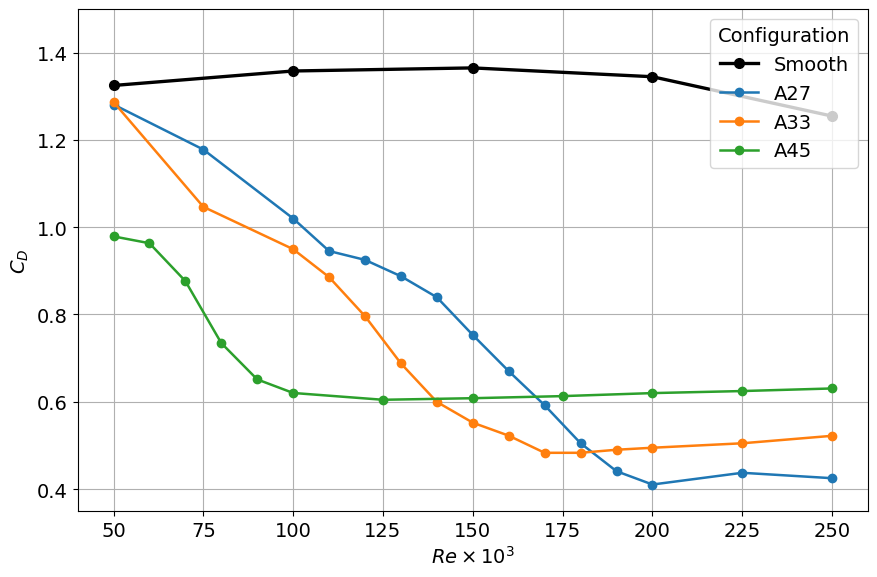

In [11]:
# Example: C_D vs Re for clean cylinder and the 0.94 mm trip wire.
# Edit angles as needed.
plot_cd_vs_re(
    results_df,
    trip_mm=[0.94,],
    include_clean=True,
    angles=[27,33,45],
    annotate=False,
    ylim=(0.35, 1.5),
    show_values = False,
    show_errorbars = False,
    show_title = False,
)


### For specific runs at different angles

In [12]:
selected_mask = (
    (
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], 0.15)
        & results_df["angle"].isin([57, 63, 69])
    )
    |
    (
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], 0.94)
        & results_df["angle"].isin([27, 33])
    )
)

selected_df = results_df[selected_mask].copy()
selected_mask = (
    (
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], 0.15)
        & results_df["angle"].isin([57, 63, 69])
    )
    |
    (
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], 0.94)
        & results_df["angle"].isin([27, 33])
    )
)

selected_df = results_df[selected_mask].copy()


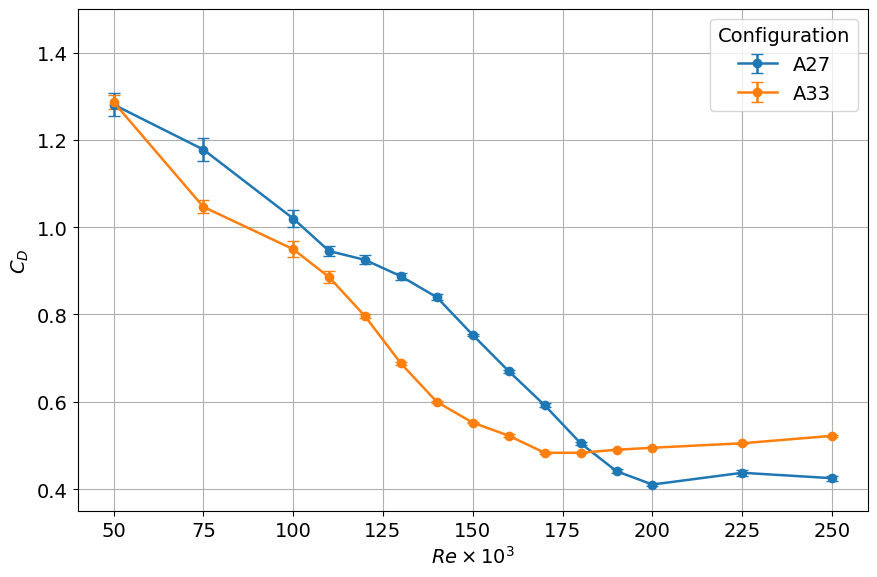

In [13]:
plot_cd_vs_re(
    selected_df,
    trip_mm=[0.15, 0.94],
    include_clean=False,
    angles=None,
    show_errorbars=True,
    show_values=False,
    show_title=False,
    ylim=(0.35, 1.5),
)


### $C_L$ plot 

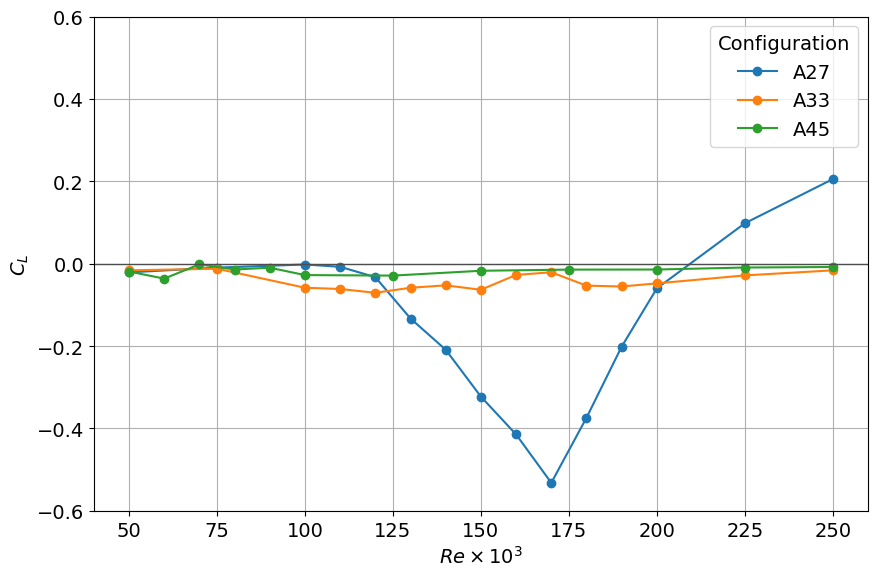

In [42]:
# Example: C_L vs Re.
plot_cl_vs_re(
    results_df,
    trip_mm=0.94,
    include_clean=False,
    angles=[27,33,45],
    ylim=(-0.6, 0.6),
    show_values = False,
    show_errorbars = False,
    show_title = False,
)


### $St$ plot (5 segments)

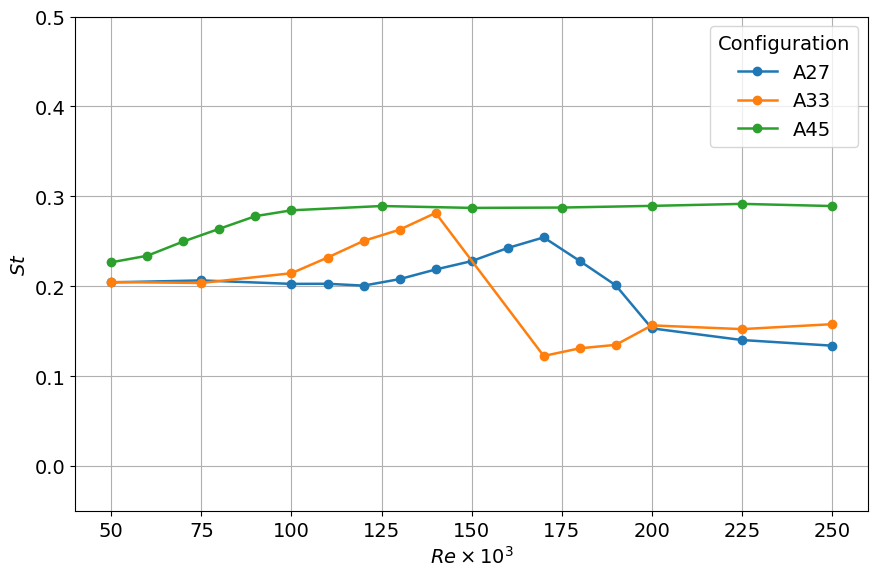

In [15]:
# Example: Strouhal number vs Re.
plot_st_vs_re(
    results_df,
    include_clean=False,
    angles=[27,33,45],
    ylim=(-0.05, 0.5),
    show_errorbars=False,
    show_values=False,
    show_title=False,
)


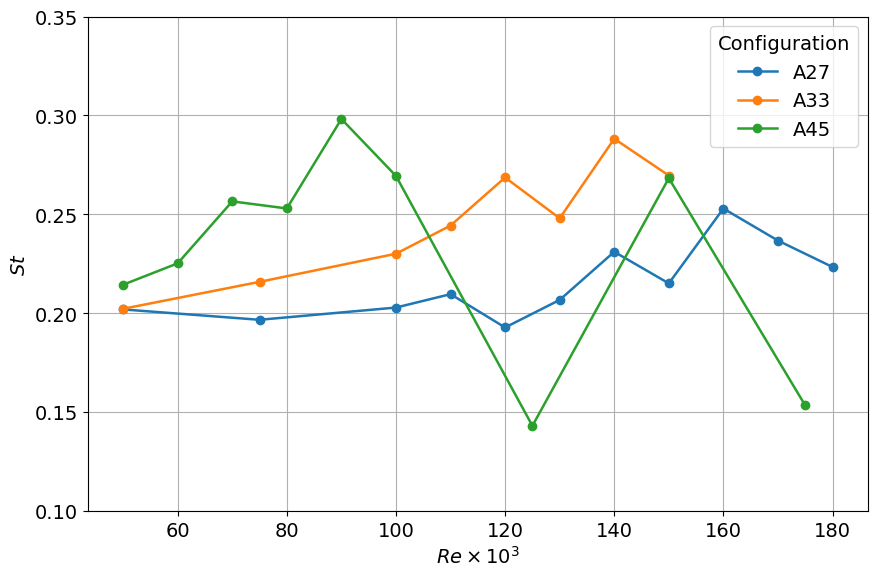

In [16]:
plot_st_vs_re(
    results_df,
    trip_mm=[0.94],
    include_clean=False,
    angles=[27, 33, 45],
    method="autocorrelation",
    ylim=(0.10, 0.35),
    show_unreliable=False,
    show_title=False,
)

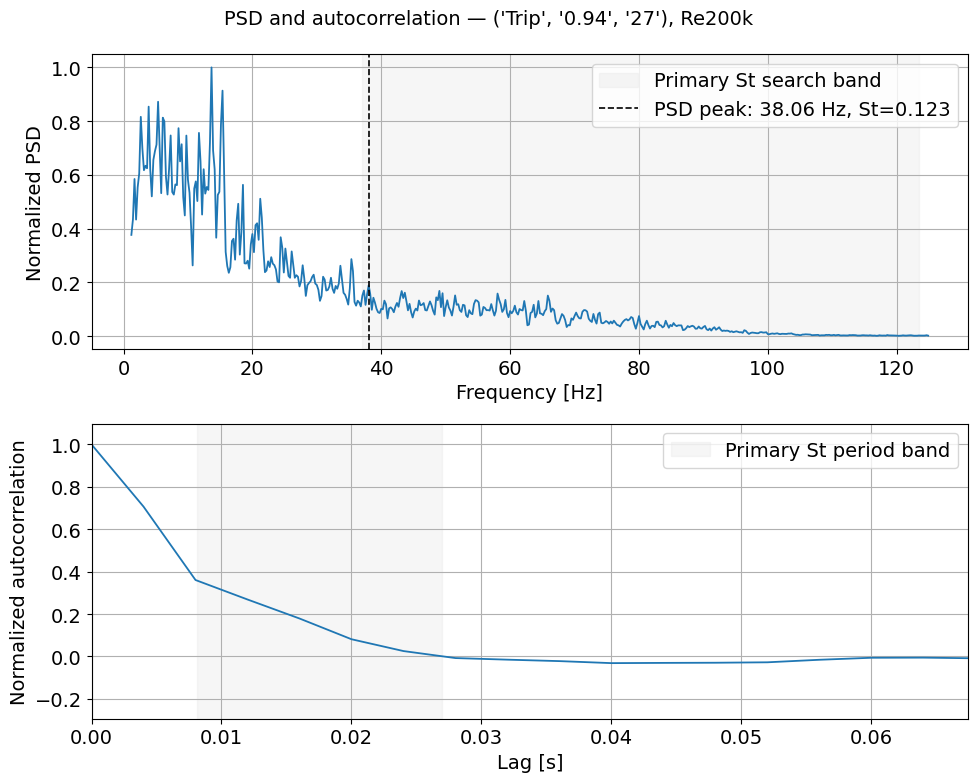

Welch PSD: f = 38.057 Hz, St = 0.1233
Autocorrelation: unavailable, quality = unreliable


In [17]:
plot_lift_psd_autocorrelation(
    ("Trip", "0.94", "27"),
    "Re200k"
)

### $St$ vs Re, 1 segment

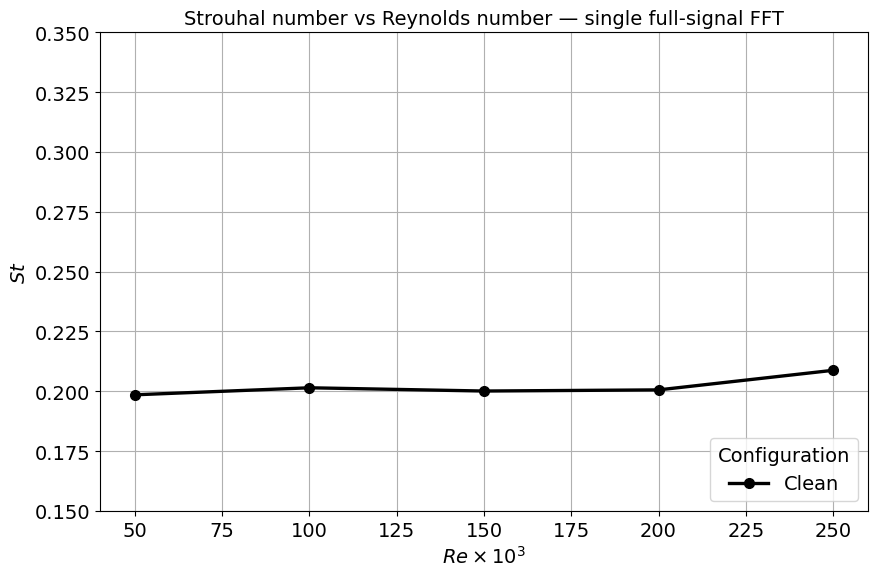

In [18]:
plot_single_st_vs_re(
    results_df,
    include_clean=True,
    angles=[],
    ylim=(0.15, 0.35)
)


### $Lift$ and $FFT$ plot 

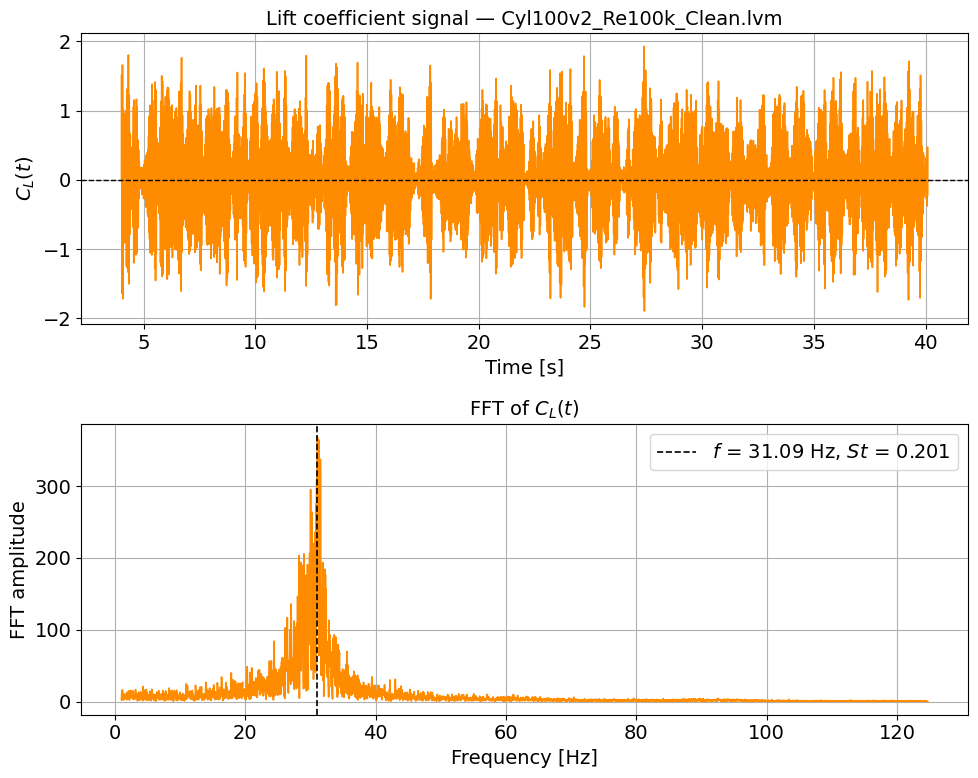

In [19]:
plot_lift_signal_and_fft(("Clean",), "Re100k")


### $Lift$ and $FFT$ 5 segments

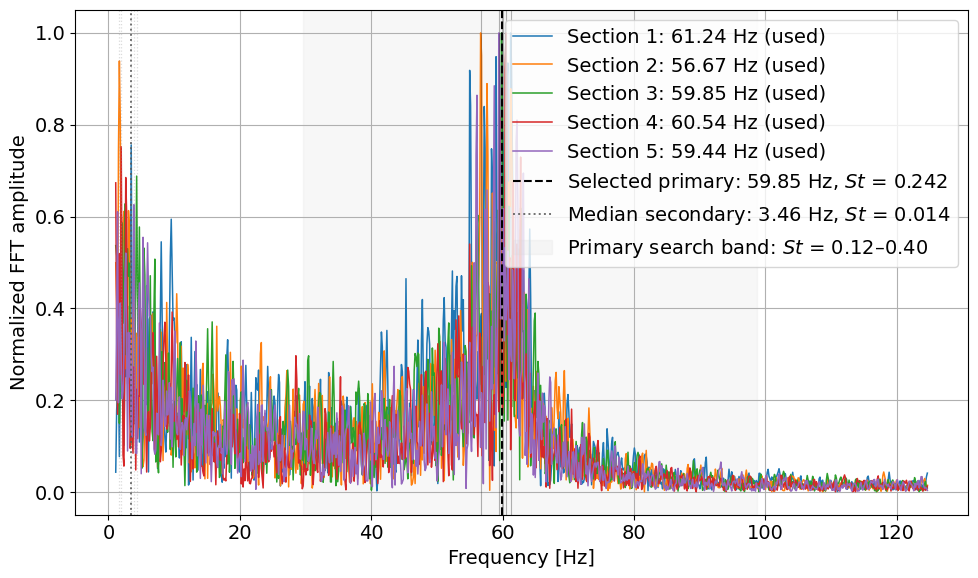

Primary-band dominant frequencies by section [Hz]:
Section 1: 61.236 Hz | amp ratio = 1.00 | used
Section 2: 56.669 Hz | amp ratio = 1.00 | used
Section 3: 59.849 Hz | amp ratio = 1.00 | used
Section 4: 60.545 Hz | amp ratio = 1.00 | used
Section 5: 59.439 Hz | amp ratio = 1.00 | used

Selected primary frequency: 59.849 Hz
Selected primary Strouhal number: 0.2424
Valid primary segments: 5/5
Relative spread of valid primary peaks: 0.029
Quality: reliable
Primary search band: 29.63–98.76 Hz

Secondary low-frequency peaks by section [Hz]:
Section 1: 3.464 Hz
Section 2: 1.663 Hz
Section 3: 4.295 Hz
Section 4: 1.940 Hz
Section 5: 3.879 Hz
Median secondary frequency: 3.464 Hz
Median secondary Strouhal number: 0.0140
Secondary search band: 1.23–24.69 Hz


In [40]:
plot_lift_fft_segments(("Trip","0.94","27",), "Re160k", n_segments=5,show_title=False)


### $C_P$ distribution plot 

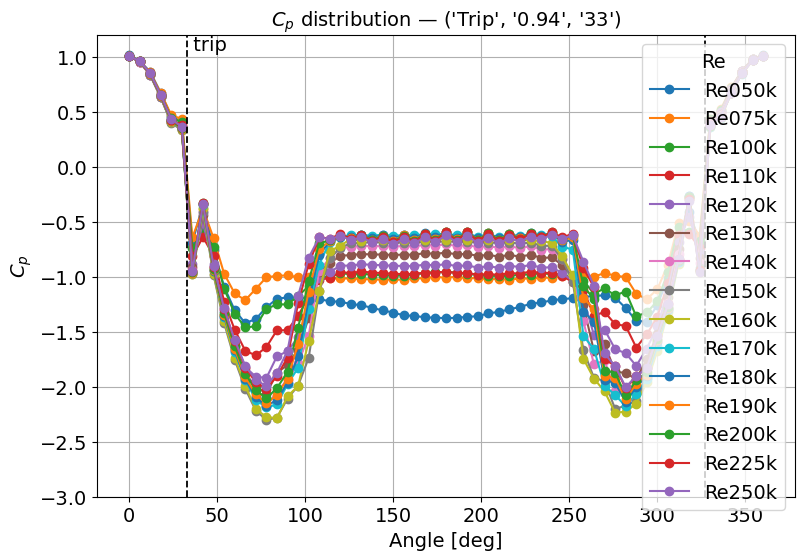

In [21]:
# Example: Cp distribution for one group.
# For clean:
# plot_cp_distribution(("Clean",), target_re=None, ylim=(-3.0, 1.2), show_title=False)
# For trip wire, uncomment and edit:
plot_cp_distribution(("Trip", "0.94", "33"), target_re=None, ylim=(-3.0, 1.2),)


### $C_P$ angular-sweep plots

Use these when one Reynolds number contains many trip-wire angles. The first plot type shows the full sweep in grey with selected cases highlighted; the second shows only the selected cases for clean interpretation.


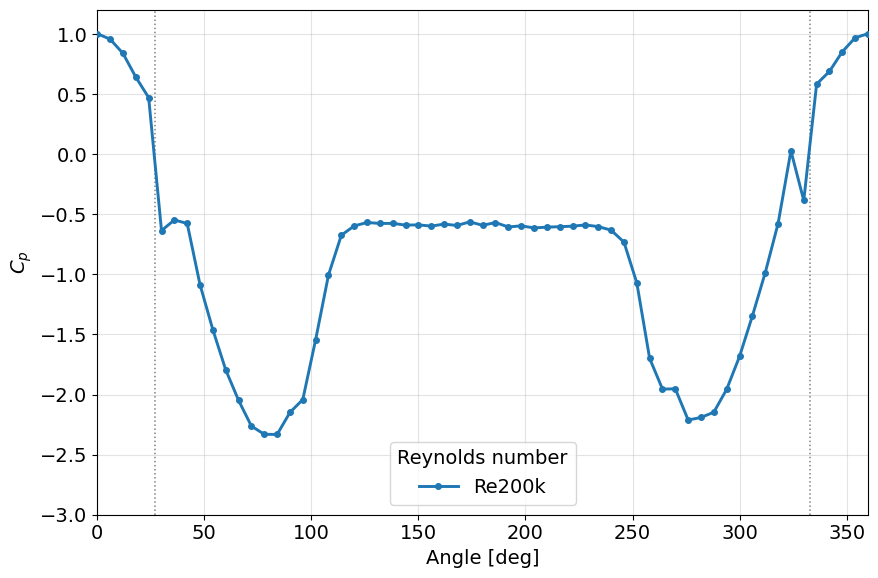

,re,trip_mm,angle,C_D,C_L,St
37,Re200k,0.94,27.0,0.410257,-0.060004,0.153032


In [22]:
# ============================================================
# Example calls: Cp angular sweep and Reynolds sweep
# ============================================================
# These examples are intentionally commented out so "Run all" does not fail
# if a particular Reynolds number or angle is not present in your data folder.

# -------------------------
# 1) Angular sweep: fixed Re, varying trip-wire angle
# -------------------------
# highlighted_angles = [27, 33, 39, 45]
# plot_cp_angular_sweep(
#     target_re="Re140k",
#     trip_mm=0.94,
#     highlight_angles=highlighted_angles,
#     mode="both",          # "overview", "selected", or "both"
#     ylim=(-3.0, 1.2),
#     show_title=False,
# )

# -------------------------
# 2) Reynolds sweep: fixed trip-wire angle, varying Re
# -------------------------
plot_cp_re_sweep(
    target_angle=27,
    trip_mm=0.94,
    reynolds_list=["Re200k"],
    include_smooth=False,  # set True to add dashed smooth reference curves
    marker_every=1,        # marker at every pressure tap
    ylim=(-3.0, 1.2),
    show_title=False,
)


### Variance and RMS

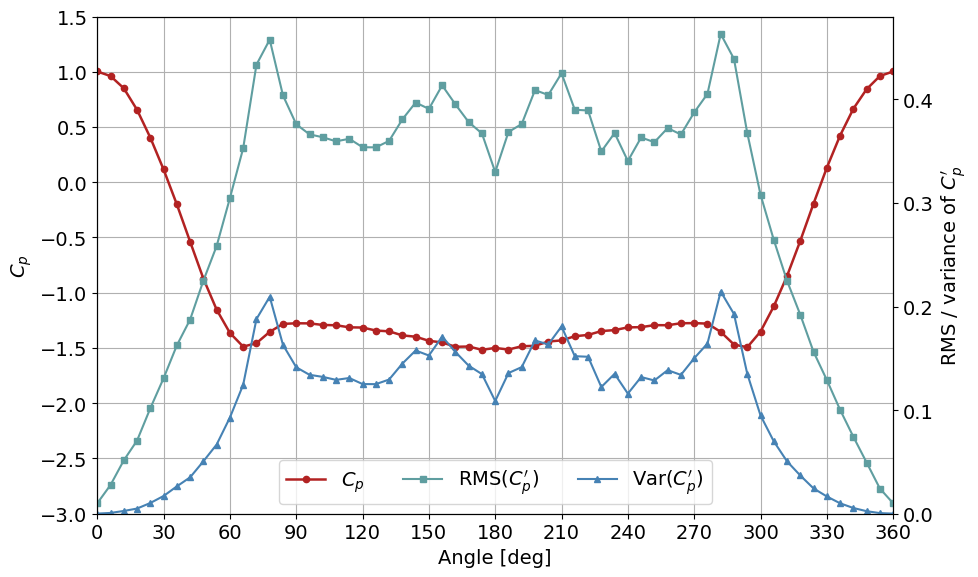

In [23]:
plot_cp_rms_variance(("Clean",), "Re100k", ylim_cp=(-3.0, 1.5), ylim_stats=(0, 0.48), show_title=False)


# All plots
# for run in get_runs(("Clean",)):
#     plot_cp_rms_variance(("Clean",), run["re"])


### $C_P$ around the cylinder plot 

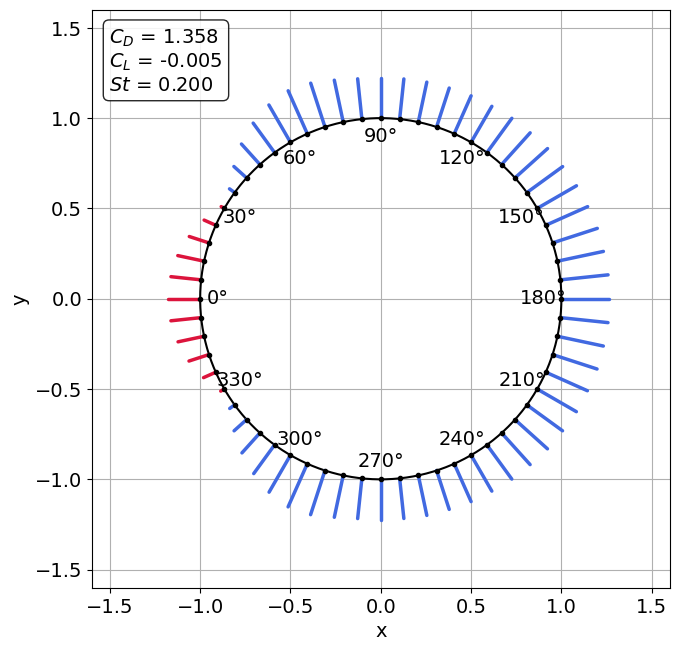

In [24]:
# Example: normal-bar plot for one run.
# Fixed cp_abs_max makes plots comparable across cases.
plot_cp_normal_bars(
    target_key=("Clean",),
    target_re="Re100k",
    cp_abs_max=2.0,
    use_magnitude=True,
    show_title=False,
)

# For a trip-wire case, uncomment and edit:
# plot_cp_normal_bars(
#     target_key=("Trip", "0.94", "27"),
#     target_re="Re100k",
#     cp_abs_max=2.0,
#     use_magnitude=True,
# )


### $C_P$ around the cylinder comparison plot 

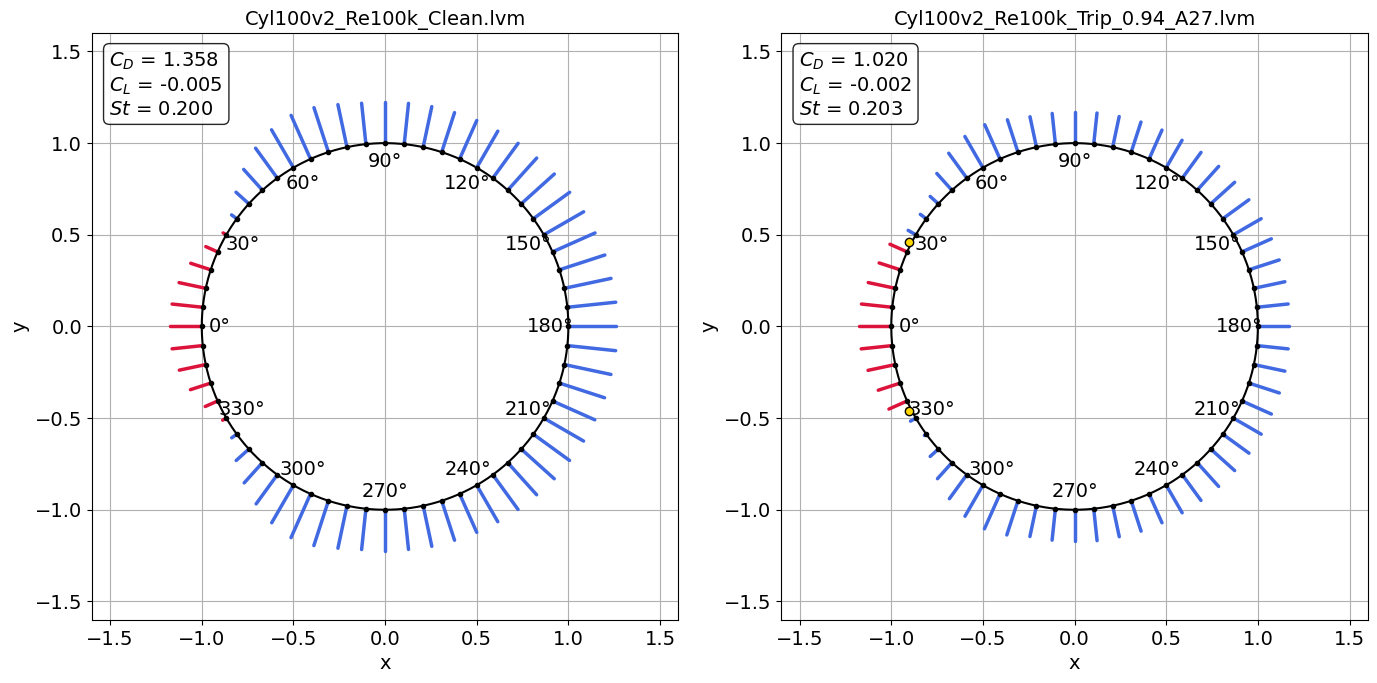

In [25]:
# Example: compare clean and trip side by side.
# Requires the selected trip case to exist in DATA_FOLDER.
compare_cp_normal_bars(
    target_key_1=("Clean",),
    target_re_1="Re100k",
    target_key_2=("Trip", "0.94", "27"),
    target_re_2="Re100k",
    cp_abs_max=2.0,
    use_magnitude=True,
)


### $Uncertaincy$ plot 

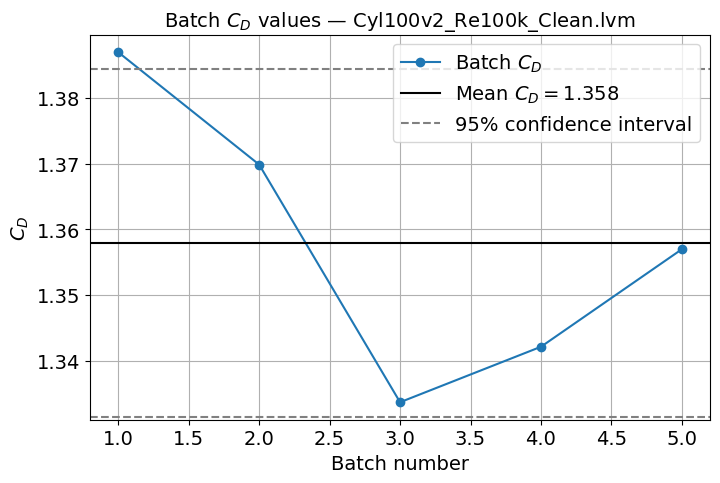

C_D = 1.3579 ± 0.0264
Batch 1: C_D = 1.3869
Batch 2: C_D = 1.3698
Batch 3: C_D = 1.3338
Batch 4: C_D = 1.3422
Batch 5: C_D = 1.3570


In [26]:
# Example: batch uncertainty plot for one run.
plot_batch_cd(("Clean",), "Re100k")


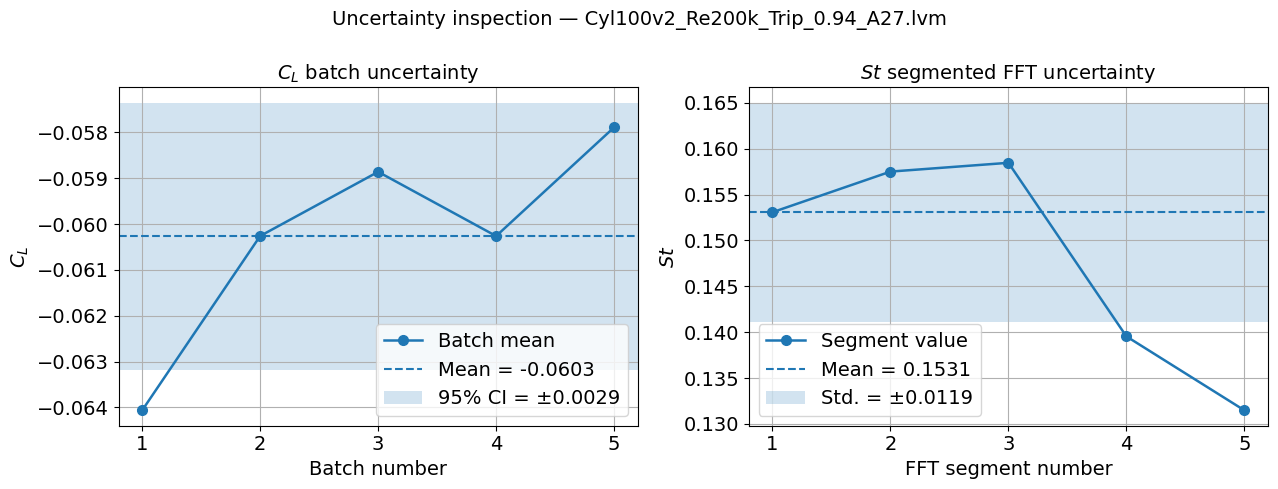

Cyl100v2_Re200k_Trip_0.94_A27.lvm

C_L batch values:


,batch,C_L_mean
0,1,-0.064065
1,2,-0.060260
2,3,-0.058860
3,4,-0.060261
4,5,-0.057889


C_L mean:     -0.06027
C_L std:      0.00235
C_L 95% CI:   ±0.00292

St segment values:


,segment,f_shedding,U_mean,St,valid_primary_peak,primary_amp_ratio
0,1,47.244315,30.864745,0.153069,True,0.390533
1,2,48.628908,30.875888,0.157498,True,0.462503
2,3,48.906802,30.864627,0.158456,True,0.587580
3,4,43.085276,30.878009,0.139534,True,0.597236
4,5,40.595736,30.877164,0.131475,True,0.418934


St mean:      0.15307
St std:       0.01194


(   batch  C_L_mean
 0      1 -0.064065
 1      2 -0.060260
 2      3 -0.058860
 3      4 -0.060261
 4      5 -0.057889,
    segment  f_shedding     U_mean        St  valid_primary_peak  \
 0        1   47.244315  30.864745  0.153069                True   
 1        2   48.628908  30.875888  0.157498                True   
 2        3   48.906802  30.864627  0.158456                True   
 3        4   43.085276  30.878009  0.139534                True   
 4        5   40.595736  30.877164  0.131475                True   
 
    primary_amp_ratio  
 0           0.390533  
 1           0.462503  
 2           0.587580  
 3           0.597236  
 4           0.418934  )

In [27]:
plot_cl_st_uncertainty_batches(("Trip", "0.94", "27"), "Re200k")


### Specific inspection

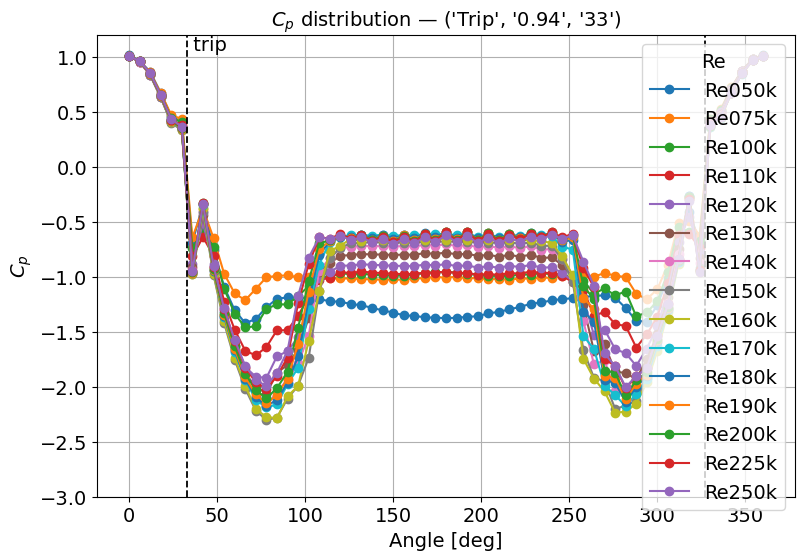

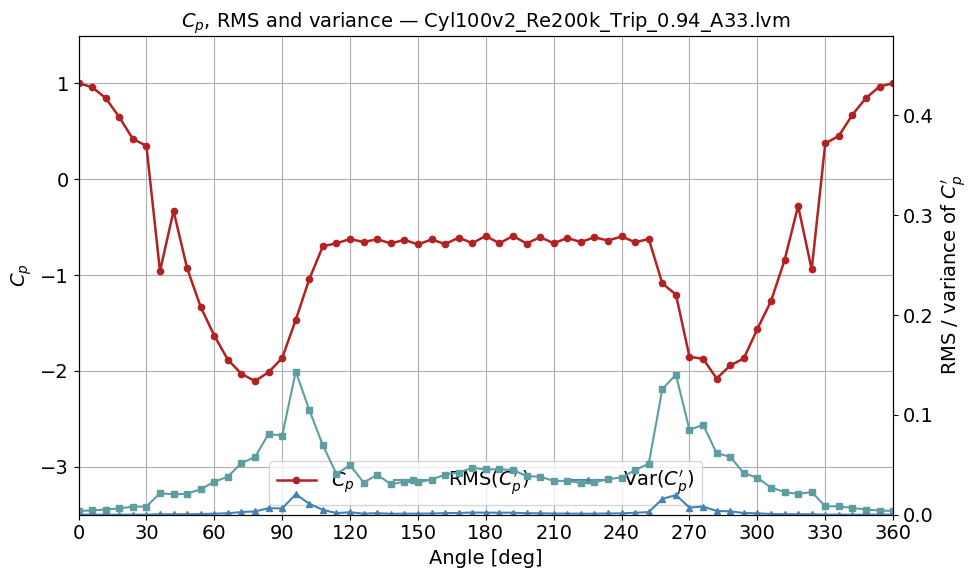

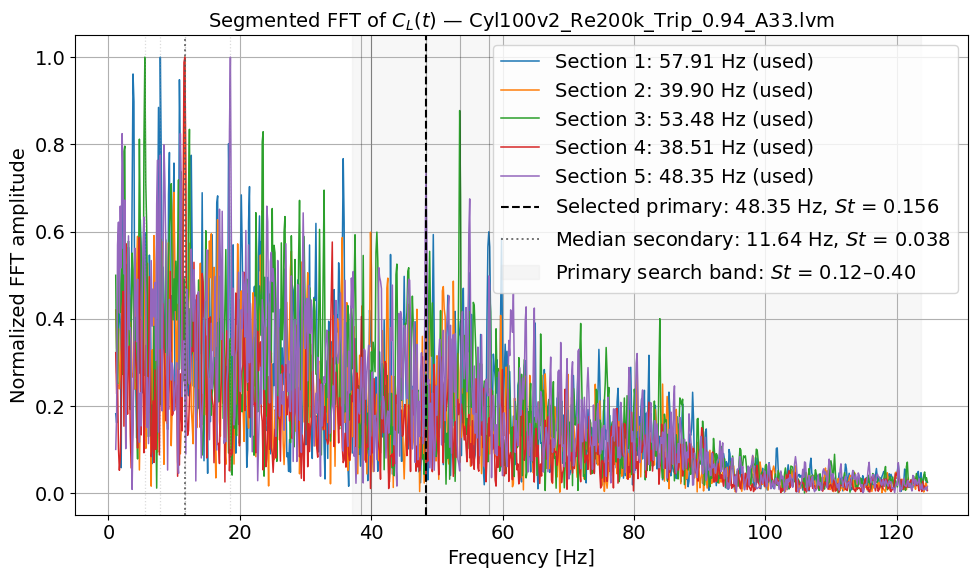

Primary-band dominant frequencies by section [Hz]:
Section 1: 57.912 Hz | amp ratio = 0.60 | used
Section 2: 39.901 Hz | amp ratio = 0.60 | used
Section 3: 53.477 Hz | amp ratio = 0.88 | used
Section 4: 38.513 Hz | amp ratio = 0.41 | used
Section 5: 48.355 Hz | amp ratio = 0.74 | used

Selected primary frequency: 48.355 Hz
Selected primary Strouhal number: 0.1563
Valid primary segments: 5/5
Relative spread of valid primary peaks: 0.174
Quality: ambiguous
Primary search band: 37.12–123.73 Hz

Secondary low-frequency peaks by section [Hz]:
Section 1: 7.897 Hz
Section 2: 11.638 Hz
Section 3: 5.542 Hz
Section 4: 11.637 Hz
Section 5: 18.566 Hz
Median secondary frequency: 11.637 Hz
Median secondary Strouhal number: 0.0376
Secondary search band: 1.55–30.93 Hz


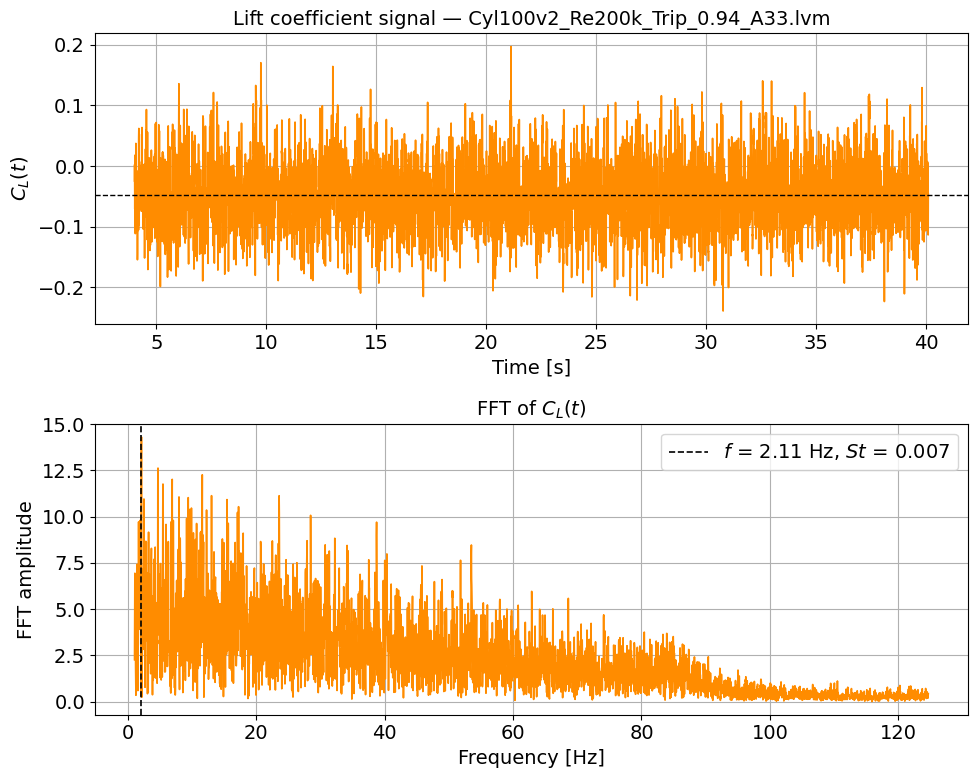

In [28]:
plot_cp_distribution(("Trip", "0.94", "33"))
plot_cp_rms_variance(("Trip", "0.94", "33"), "Re200k", ylim_cp=(-3.5, 1.5), ylim_stats=(0, 0.48))
plot_lift_fft_segments(("Trip", "0.94", "33"), "Re200k", n_segments=5)
plot_lift_signal_and_fft(("Trip", "0.94", "33"), "Re200k")


## 7. Inspect extra channels

In [29]:
def summarize_extra_channels(target_key=None, target_re=None):
    """
    Summarize pitot, tunnel velocity, density, time, etc.

    target_key=None gives all runs.
    """
    selected_runs = runs

    if target_key is not None:
        selected_runs = get_runs(target_key, target_re=target_re)

    rows = []

    for run in selected_runs:
        extra = run["extra_data"]

        for col in EXTRA_NAMES:
            s = extra[col]
            rows.append({
                "file": run["file_name"],
                "re": run["re"],
                "case": run["case"],
                "trip_mm": run["trip_mm"],
                "angle": run["angle"],
                "variable": col,
                "mean": s.mean(),
                "std": s.std(),
                "min": s.min(),
                "max": s.max(),
            })

    return pd.DataFrame(rows)


extra_summary = summarize_extra_channels()
display(extra_summary.head(20))


,file,re,case,trip_mm,angle,variable,mean,std,min,max
0,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,pitot,35.753948,7.679387e-01,30.664125,41.342487
1,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,AoA,0.001000,4.337026e-19,0.001000,0.001000
2,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,F,-0.218186,2.745563e-02,-0.355432,-0.099042
3,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,alpha,0.046792,2.007344e-01,-0.292469,0.440362
4,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,P_m,35.754835,1.249446e-01,35.414814,36.147964
5,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,V_tunnel,7.832404,1.368166e-02,7.795085,7.875358
6,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,rho,1.165664,2.220557e-16,1.165664,1.165664
7,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,time,20.047885,1.157569e+01,-0.000021,40.095122
8,Cyl100v2_Re050k_Trip_0.94_A27.lvm,Re050k,Trip,0.94,27.0,pitot,34.862855,7.302419e-01,29.986866,41.713993
9,Cyl100v2_Re050k_Trip_0.94_A27.lvm,Re050k,Trip,0.94,27.0,AoA,0.001000,4.337026e-19,0.001000,0.001000


In [30]:
# Optional: plot one extra channel across all runs.
def plot_extra_channel(channel="pitot", target_key=None, show_title=True):
    selected_runs = runs if target_key is None else get_runs(target_key)

    fig, ax = plt.subplots(figsize=(10, 5))

    for run in selected_runs:
        ax.plot(
            run["extra_data"].index,
            run["extra_data"][channel],
            label=run["file_name"],
            alpha=0.9,
        )

    ax.set_xlabel("Sample number")
    ax.set_ylabel(channel)
    if show_title:
        ax.set_title(f"{channel} across selected files")
    ax.grid(True)
    ax.legend()
    plt.show()


# Example:
# plot_extra_channel("pitot")
# plot_extra_channel("V_tunnel", target_key=("Clean",))


## 8. Notes

Important assumptions in this notebook:

1. The dynamic pressure channel is column 64 in 1-based indexing, i.e. Python index `63`.
2. Layer 1 is interpreted as the taps at \(0^\circ, 12^\circ, \ldots, 348^\circ\).
3. Layer 2 is interpreted as the taps at \(6^\circ, 18^\circ, \ldots, 354^\circ\).
4. \(C_D\) and \(C_L\) use the same sign convention as your previous working notebook.
5. The Strouhal number is computed from the time-resolved \(C_L(t)\) signal. This is often more robust than using a single pressure tap, but it may differ slightly from Gamst's tap-based method.

If you want strict consistency with Gamst's method, the next useful addition would be a second Strouhal calculation based on a chosen pressure tap, for example tap 24 / approximately \(138^\circ\), and then comparing it against the \(C_L(t)\)-based value.


In [31]:
# In the Day 2 notebook, run:

results_day2 = results_df.copy()
results_day2["test_day"] = "Day 2"
results_day2.to_csv("results_day2.csv", index=False)


In [32]:
# =========================
# Example calls: compare Strouhal extraction methods
# =========================
# The notebook now computes several possible shedding-frequency estimates:
#   method="segments"   -> quality-controlled segmented FFT (recommended default)
#   method="welch"      -> Welch-averaged PSD, smoother spectral estimate
#   method="time_peaks" -> peak-to-peak timing in C_L(t), time-domain cross-check
#   method="autocorrelation" -> autocorrelation period estimate
#   method="pressure_tap" -> rear pressure tap spectra, Gamst-style cross-check
#   method="single"     -> one full-signal FFT, useful mainly as a diagnostic

# Recommended default St plot:
# plot_st_vs_re(
#     results_df,
#     trip_mm=[0.94],
#     include_clean=False,
#     angles=[27, 33, 45],
#     method="segments",
#     ylim=(0.10, 0.35),
#     show_unreliable=False,
#     show_title=False,
# )

# Welch PSD cross-check:
# plot_st_vs_re(
#     results_df,
#     trip_mm=[0.94],
#     include_clean=False,
#     angles=[27, 33, 45],
#     method="welch",
#     ylim=(0.10, 0.35),
#     show_unreliable=False,
#     show_title=False,
# )

# Time-domain peak-spacing cross-check:
# plot_st_vs_re(
#     results_df,
#     trip_mm=[0.94],
#     include_clean=False,
#     angles=[27, 33, 45],
#     method="time_peaks",
#     ylim=(0.10, 0.35),
#     show_unreliable=False,
#     show_title=False,
# )

# Quick method comparison as separate plots:
# plot_st_method_comparison(
#     results_df,
#     trip_mm=[0.94],
#     include_clean=False,
#     angles=[27, 33, 45],
#     methods=("segments", "welch", "time_peaks", "autocorrelation"),
#     ylim=(0.10, 0.35),
#     show_unreliable=False,
#     show_title=False,
# )


# Pressure-tap / Gamst-style cross-check:
# plot_st_vs_re(
#     results_df,
#     trip_mm=[0.94],
#     include_clean=False,
#     angles=[27, 33, 45],
#     method="pressure_tap",
#     ylim=(0.10, 0.35),
#     show_unreliable=False,
#     show_title=False,
# )

# Diagnostic pressure tap spectra for one case:
# plot_pressure_tap_spectra(("Trip", "0.94", "27"), "Re150k")
# Strict one-tap version around Gamst's 138 degree tap:
# plot_pressure_tap_spectra(("Trip", "0.94", "27"), "Re150k", tap_angles=(138,))


# Autocorrelation-based St plot:
# plot_st_vs_re(
#     results_df,
#     trip_mm=[0.94],
#     include_clean=False,
#     angles=[27, 33, 45],
#     method="autocorrelation",
#     ylim=(0.10, 0.35),
#     show_unreliable=False,
#     show_title=False,
# )

# Diagnostic PSD + autocorrelation plot for one case:
# plot_lift_psd_autocorrelation(("Trip", "0.94", "27"), "Re150k")


## CFD Strouhal extraction from STAR-CCM+ monitor CSV files

This section reads STAR-CCM+ monitor exports, estimates the dominant shedding frequency from the unsteady lift signal, computes

\[
St = \frac{fD}{U_\infty},
\]

and overlays the CFD points on the existing experimental `plot_st_vs_re` style. The CSV files only contain time and monitor value, so the Reynolds number and velocity must be supplied in `CFD_RUNS` below.

In [43]:
# ============================================================
# CFD Strouhal extraction from STAR-CCM+ CL monitor CSV files
# ============================================================
# The uploaded STAR-CCM+ monitor CSVs only contain time and CL.
# Therefore Re, D and either U_inf or nu must be supplied here.
#
# IMPORTANT:
# - Re is used for the x-axis when overlaying CFD on the experimental plot.
# - U_inf and D are used to convert f -> St.
# - If U_inf is None, the code computes U_inf = Re * nu / D.
# - The default Re=200000 is only a placeholder matching the common Re200k case
#   in this notebook. Change it if these CFD runs are at another Reynolds number.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    display = print

# Folder containing the CFD monitor CSV files.
# Use Path.cwd() if the CSV files are in the same folder as the notebook.
CFD_MONITOR_FOLDER = Path("C:\Users\mpciv\Downloads")

# Default values. The code will use the notebook D if it exists.
CFD_DEFAULT_D = D if "D" in globals() else 0.100       # [m]
CFD_DEFAULT_NU = 1.50e-5                              # [m^2/s], adjust if needed
CFD_DEFAULT_RE = 200000                               # placeholder; change if needed

# Frequency extraction settings.
# "broad" searches a broad frequency range and is safer if U/D is not yet certain.
# "st_band" only searches the physically expected shedding band below.
CFD_FREQUENCY_SEARCH_MODE = "broad"   # "broad" or "st_band"
CFD_USE_WELCH = False                  # False = full-signal FFT; recommended for these short 0.5 s files
CFD_ST_SEARCH_RANGE = (0.05, 0.45)     # only used when CFD_FREQUENCY_SEARCH_MODE = "st_band"
CFD_F_MIN = 1.0                        # Hz, used for broad search
CFD_F_MAX = 500.0                      # Hz, clipped automatically by Nyquist frequency
CFD_REMOVE_FIRST_FRAC = 0.10           # remove initial transient before FFT/PSD

# Editable metadata for the four CFD monitor files.
# If you know U_inf directly, put it in U_inf and the code computes Re if needed.
# If U_inf is None, the code computes it from Re, nu and D.
CFD_RUNS = [
    {"label": "CFD smooth", "file": "Smooth_CL.csv", "case": "Clean", "angle": np.nan,
     "Re": CFD_DEFAULT_RE, "D": CFD_DEFAULT_D, "U_inf": None, "nu": CFD_DEFAULT_NU},

    {"label": "CFD A27", "file": "27deg_CL.csv", "case": "Trip", "angle": 27,
     "Re": CFD_DEFAULT_RE, "D": CFD_DEFAULT_D, "U_inf": None, "nu": CFD_DEFAULT_NU},

    {"label": "CFD A33", "file": "33deg_CL.csv", "case": "Trip", "angle": 33,
     "Re": CFD_DEFAULT_RE, "D": CFD_DEFAULT_D, "U_inf": None, "nu": CFD_DEFAULT_NU},

    {"label": "CFD A45", "file": "45deg_CL.csv", "case": "Trip", "angle": 45,
     "Re": CFD_DEFAULT_RE, "D": CFD_DEFAULT_D, "U_inf": None, "nu": CFD_DEFAULT_NU},
]

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (961388612.py, line 25)

In [ ]:
def _resolve_monitor_path(file_name, folder=CFD_MONITOR_FOLDER):
    """Find a STAR-CCM+ monitor CSV either by absolute path, relative path, or in the selected folder."""
    candidates = [Path(file_name), folder / file_name, Path.cwd() / file_name]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {file_name!r}. Put the CSV in the notebook folder, "
        f"or change CFD_MONITOR_FOLDER. Tried: {candidates}"
    )


def read_star_monitor_csv(file_path):
    """
    Read a STAR-CCM+ monitor CSV.

    Expected format:
        Time, monitor value

    The second column can be named CL Monitor, Cd Monitor, etc.; the function simply
    reads the first two numeric columns.
    """
    df = pd.read_csv(file_path)
    if df.shape[1] < 2:
        raise ValueError(f"{file_path} must contain at least two columns: time and monitor value.")

    time = pd.to_numeric(df.iloc[:, 0], errors="coerce").to_numpy(dtype=float)
    signal = pd.to_numeric(df.iloc[:, 1], errors="coerce").to_numpy(dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    order = np.argsort(time)
    time = time[order]
    signal = signal[order]

    # Remove duplicate time entries if present.
    unique_time, unique_idx = np.unique(time, return_index=True)
    time = unique_time
    signal = signal[unique_idx]

    if len(time) < 20:
        raise ValueError(f"{file_path} contains too few valid samples after cleaning.")

    return time, signal, list(df.columns)


def _parabolic_peak_refinement(freqs, spectrum, peak_idx):
    """
    Refine the dominant frequency estimate using a parabolic interpolation around the peak.
    This gives a smoother estimate than the raw FFT bin when the record is short.
    """
    if peak_idx <= 0 or peak_idx >= len(spectrum) - 1:
        return freqs[peak_idx]

    y0 = np.log(max(spectrum[peak_idx - 1], 1e-300))
    y1 = np.log(max(spectrum[peak_idx],     1e-300))
    y2 = np.log(max(spectrum[peak_idx + 1], 1e-300))

    denom = y0 - 2*y1 + y2
    if abs(denom) < 1e-14:
        return freqs[peak_idx]

    delta = 0.5 * (y0 - y2) / denom
    delta = np.clip(delta, -1.0, 1.0)
    df = freqs[1] - freqs[0]
    return freqs[peak_idx] + delta * df


def estimate_dominant_frequency(time,
                                signal,
                                f_min=CFD_F_MIN,
                                f_max=CFD_F_MAX,
                                remove_first_frac=CFD_REMOVE_FIRST_FRAC,
                                use_welch=True):
    """
    Estimate dominant frequency using Welch PSD if scipy is available, otherwise FFT.

    Returns a dictionary with frequency, peak strength and diagnostic arrays.
    """
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    start = int(len(time) * remove_first_frac)
    time = time[start:]
    signal = signal[start:]

    signal = signal - np.nanmean(signal)
    dt = np.median(np.diff(time))
    fs = 1.0 / dt
    nyquist = 0.5 * fs
    f_max = min(float(f_max), 0.98 * nyquist)

    if f_min >= f_max:
        raise ValueError(f"Invalid frequency search range: f_min={f_min}, f_max={f_max}")

    method_used = "fft"
    try:
        if use_welch:
            from scipy.signal import welch
            nperseg = min(256, len(signal))
            if nperseg < 32:
                raise ValueError("Signal too short for Welch PSD.")
            noverlap = int(0.5 * nperseg)
            freqs, spectrum = welch(
                signal,
                fs=fs,
                window="hann",
                nperseg=nperseg,
                noverlap=noverlap,
                detrend="constant",
                scaling="density",
            )
            method_used = "welch"
        else:
            raise ImportError
    except Exception:
        window = np.hanning(len(signal))
        freqs = np.fft.rfftfreq(len(signal), d=dt)
        spectrum = np.abs(np.fft.rfft(signal * window))**2
        method_used = "fft"

    mask = (freqs >= f_min) & (freqs <= f_max)
    if not np.any(mask):
        raise ValueError("No frequency bins inside the selected search range.")

    freqs_band = freqs[mask]
    spectrum_band = spectrum[mask]
    local_peak_idx = int(np.argmax(spectrum_band))
    f_raw = freqs_band[local_peak_idx]

    # Refine only for uniformly spaced FFT/Welch bins.
    f_refined = _parabolic_peak_refinement(freqs_band, spectrum_band, local_peak_idx)

    total_power = np.trapz(spectrum_band, freqs_band) if len(freqs_band) > 1 else spectrum_band.sum()
    peak_power = spectrum_band[local_peak_idx]
    peak_ratio = peak_power / np.nanmax(spectrum_band) if np.nanmax(spectrum_band) > 0 else np.nan

    return {
        "f": float(f_refined),
        "f_raw_bin": float(f_raw),
        "peak_power": float(peak_power),
        "peak_ratio": float(peak_ratio),
        "total_power_band": float(total_power),
        "method": method_used,
        "sampling_frequency": float(fs),
        "n_samples_used": int(len(signal)),
        "freqs": freqs,
        "spectrum": spectrum,
        "freqs_band": freqs_band,
        "spectrum_band": spectrum_band,
    }


def build_cfd_strouhal_df(cfd_runs=CFD_RUNS,
                          folder=CFD_MONITOR_FOLDER,
                          frequency_search_mode=CFD_FREQUENCY_SEARCH_MODE,
                          st_search_range=CFD_ST_SEARCH_RANGE):
    """Read all CFD monitor CSVs and return a summary DataFrame with f and St."""
    rows = []

    for run in cfd_runs:
        file_path = _resolve_monitor_path(run["file"], folder=folder)
        time, signal, columns = read_star_monitor_csv(file_path)

        D_run = float(run.get("D", CFD_DEFAULT_D))
        nu_run = float(run.get("nu", CFD_DEFAULT_NU))
        Re_run = run.get("Re", np.nan)
        U_run = run.get("U_inf", None)

        if U_run is None or (isinstance(U_run, float) and np.isnan(U_run)):
            if Re_run is None or not np.isfinite(float(Re_run)):
                raise ValueError(f"{run['label']}: supply either U_inf or Re.")
            U_run = float(Re_run) * nu_run / D_run
        else:
            U_run = float(U_run)

        if Re_run is None or not np.isfinite(float(Re_run)):
            Re_run = U_run * D_run / nu_run
        else:
            Re_run = float(Re_run)

        if frequency_search_mode == "st_band":
            f_min = st_search_range[0] * U_run / D_run
            f_max = st_search_range[1] * U_run / D_run
        elif frequency_search_mode == "broad":
            f_min = CFD_F_MIN
            f_max = CFD_F_MAX
        else:
            raise ValueError("frequency_search_mode must be 'broad' or 'st_band'.")

        freq_info = estimate_dominant_frequency(
            time,
            signal,
            f_min=f_min,
            f_max=f_max,
            remove_first_frac=CFD_REMOVE_FIRST_FRAC,
            use_welch=CFD_USE_WELCH,
        )

        f = freq_info["f"]
        St = f * D_run / U_run

        rows.append({
            "label": run["label"],
            "file": run["file"],
            "case": run.get("case", "CFD"),
            "angle": run.get("angle", np.nan),
            "Re": Re_run,
            "D": D_run,
            "U_inf": U_run,
            "nu": nu_run,
            "f_Hz": f,
            "f_raw_bin_Hz": freq_info["f_raw_bin"],
            "St": St,
            "signal_mean": float(np.mean(signal)),
            "signal_rms": float(np.sqrt(np.mean((signal - np.mean(signal))**2))),
            "monitor_column": columns[1],
            "frequency_method": freq_info["method"],
            "n_samples_used": freq_info["n_samples_used"],
            "sampling_frequency_Hz": freq_info["sampling_frequency"],
            "search_f_min_Hz": f_min,
            "search_f_max_Hz": f_max,
            "_time": time,
            "_signal": signal,
            "_freq_info": freq_info,
        })

    cfd_df = pd.DataFrame(rows)
    display_cols = [
        "label", "Re", "U_inf", "D", "f_Hz", "St", "signal_rms",
        "monitor_column", "frequency_method", "search_f_min_Hz", "search_f_max_Hz"
    ]
    display(cfd_df[display_cols])
    return cfd_df


cfd_st_df = build_cfd_strouhal_df()

,label,Re,U_inf,D,f_Hz,St,signal_rms,monitor_column,frequency_method,search_f_min_Hz,search_f_max_Hz
0,CFD smooth,200000.0,30.0,0.1,23.658237,0.078861,0.149054,CL Monitor: CL Monitor,fft,1.0,500.0
1,CFD A27,200000.0,30.0,0.1,15.173461,0.050578,0.093933,CL Monitor: CL Monitor,fft,1.0,500.0
2,CFD A33,200000.0,30.0,0.1,24.512775,0.081709,0.087318,CL Monitor: CL Monitor,fft,1.0,500.0
3,CFD A45,200000.0,30.0,0.1,17.051670,0.056839,0.125049,CL Monitor: CL Monitor,fft,1.0,500.0


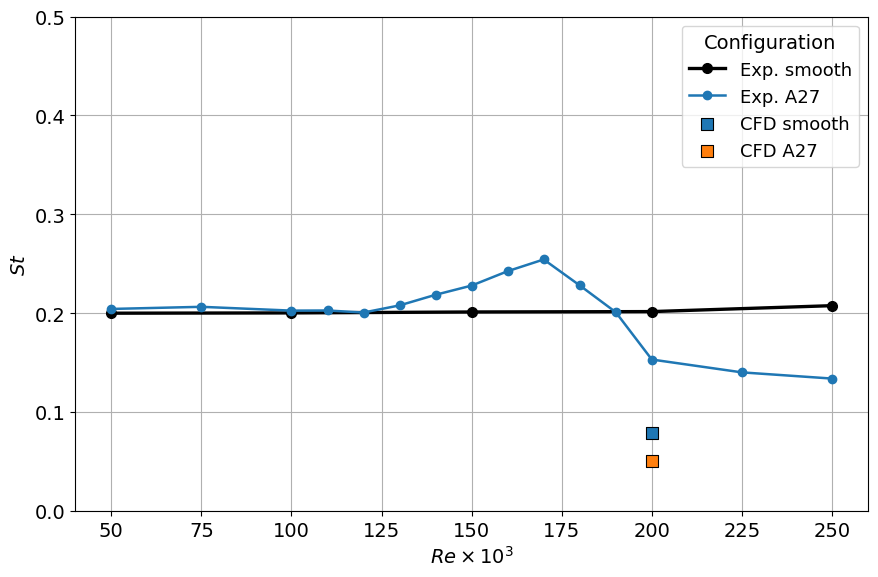

In [45]:
def plot_cfd_monitor_diagnostics(cfd_df=None, labels=None, normalize_psd=True):
    """
    Plot the monitor signal and PSD for selected CFD cases.

    This is useful for checking whether the reported frequency is a clear peak or a weak/noisy estimate.
    """
    if cfd_df is None:
        cfd_df = cfd_st_df

    if labels is not None:
        cfd_df = cfd_df[cfd_df["label"].isin(labels)]

    for _, row in cfd_df.iterrows():
        time = row["_time"]
        signal = row["_signal"]
        freq_info = row["_freq_info"]
        freqs = freq_info["freqs"]
        spectrum = freq_info["spectrum"].copy()

        if normalize_psd and np.nanmax(spectrum) > 0:
            spectrum = spectrum / np.nanmax(spectrum)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(time, signal, linewidth=1.2)
        axes[0].set_xlabel("Time [s]")
        axes[0].set_ylabel("Monitor value")
        axes[0].set_title(f"{row['label']} monitor")
        axes[0].grid(True)

        axes[1].plot(freqs, spectrum, linewidth=1.4)
        axes[1].axvline(row["f_Hz"], color="black", linestyle="--", linewidth=1.2,
                        label=f"f = {row['f_Hz']:.2f} Hz, St = {row['St']:.3f}")
        axes[1].axvspan(row["search_f_min_Hz"], row["search_f_max_Hz"], color="0.8", alpha=0.4,
                        label="Search band")
        axes[1].set_xlim(0, min(CFD_F_MAX, 0.5 * row["sampling_frequency_Hz"]))
        axes[1].set_xlabel("Frequency [Hz]")
        axes[1].set_ylabel("Normalized PSD" if normalize_psd else "PSD")
        axes[1].set_title(f"{row['label']} spectrum")
        axes[1].grid(True)
        axes[1].legend()

        plt.tight_layout()
        plt.show()


def plot_st_vs_re_with_cfd(results_df,
                           cfd_df=None,
                           trip_mm=None,
                           include_clean=True,
                           angles=None,
                           method="segments",
                           ylim=None,
                           show_values=False,
                           show_title=True,
                           show_unreliable=False):
    """
    Overlay CFD Strouhal values on the existing experimental St-vs-Re plot.

    The experimental part uses the same filtering logic as plot_st_vs_re, while the CFD
    points are plotted as square markers at the Re values defined in CFD_RUNS.
    """
    if cfd_df is None:
        cfd_df = cfd_st_df

    method_info = st_method_columns(method)
    st_col = method_info["st"]
    quality_col = method_info["quality"]
    valid_qualities = method_info["valid_qualities"]
    method_label = method_info["label"]

    fig, ax = plt.subplots(figsize=(9, 6))

    def _filter_experimental_quality(df):
        df = df.copy()
        if (not show_unreliable) and quality_col is not None and quality_col in df.columns:
            df = df[df[quality_col].isin(valid_qualities)]
        return df[np.isfinite(df[st_col])]

    def _plot_experimental_group(df, label, color=None, linewidth=1.8, markersize=6):
        df = df.sort_values("Re")
        if df.empty:
            return
        ax.plot(
            re_axis_values(df["Re"]),
            df[st_col],
            "o-",
            color=color,
            linewidth=linewidth,
            markersize=markersize,
            label=label,
        )
        if show_values:
            add_value_labels(ax, re_axis_values(df["Re"]), df[st_col], fmt="{:.3f}")

    # Experimental smooth case.
    if include_clean:
        clean_df = _filter_experimental_quality(results_df[results_df["case"] == "Clean"])
        _plot_experimental_group(clean_df, "Exp. smooth", color="black", linewidth=2.4, markersize=7)

    # Experimental trip cases.
    trip_df = results_df[results_df["case"] == "Trip"].copy()
    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]
    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]
    trip_df = _filter_experimental_quality(trip_df)

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        _plot_experimental_group(group, f"Exp. A{int(angle)}")

    # CFD overlay.
    cfd_plot_df = cfd_df.copy()
    if not include_clean:
        cfd_plot_df = cfd_plot_df[cfd_plot_df["case"] != "Clean"]
    if angles is not None:
        cfd_plot_df = cfd_plot_df[(cfd_plot_df["case"] == "Clean") | cfd_plot_df["angle"].isin(angles)]

    for _, row in cfd_plot_df.iterrows():
        ax.scatter(
            row["Re"] / RE_AXIS_SCALE if "RE_AXIS_SCALE" in globals() else row["Re"] / 1000.0,
            row["St"],
            marker="s",
            s=85,
            edgecolor="black",
            linewidth=0.8,
            zorder=10,
            label=row["label"],
        )
        if show_values:
            ax.annotate(
                f"{row['St']:.3f}",
                xy=(row["Re"] / RE_AXIS_SCALE if "RE_AXIS_SCALE" in globals() else row["Re"] / 1000.0, row["St"]),
                xytext=(0, 9),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=FIG_FONT_SIZE if "FIG_FONT_SIZE" in globals() else 10,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="0.75", alpha=0.9),
            )

    ax.set_xlabel(RE_AXIS_LABEL if "RE_AXIS_LABEL" in globals() else r"$Re \times 10^3$")
    ax.set_ylabel("$St$")

    if show_title:
        ax.set_title(f"Experimental and CFD Strouhal number — {method_label}")
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", fontsize=(FIG_FONT_SIZE - 1 if "FIG_FONT_SIZE" in globals() else 9))
    plt.tight_layout()
    plt.show()


# Main overlay plot. Adjust include_clean / angles / ylim as needed.
plot_st_vs_re_with_cfd(
    results_df,
    cfd_df=cfd_st_df,
    trip_mm=[0.94],
    include_clean=True,
    angles=[27],
    method="segments",
    ylim=(0.00, 0.50),
    show_values=False,
    show_title=False,
)

# Optional diagnostic plots. Uncomment if you want to inspect the spectra.
# plot_cfd_monitor_diagnostics(cfd_st_df)

# Optional export of the CFD St values.
# cfd_st_df.drop(columns=["_time", "_signal", "_freq_info"]).to_csv("cfd_strouhal_summary.csv", index=False)